## Анализ временного ряда

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')
labels_df  = pd.read_csv('test_label.csv')
labels_df


,timestamp_(min),label
0,132480.0,0
1,132481.0,0
2,132482.0,0
3,132483.0,0
4,132484.0,0
...,...,...
87836,220316.0,0
87837,220317.0,0
87838,220318.0,0
87839,220319.0,0


In [33]:
train_df

,timestamp_(min),feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24
0,0.0,0.732689,0.761748,0.606848,0.488746,0.424310,0.403609,0.519318,0.398792,0.451453,...,0.318797,0.451856,0.571500,0.469717,0.609883,0.008432,0.000000,0.481838,0.006536,0.138249
1,1.0,0.732799,0.761855,0.607133,0.488781,0.432008,0.410256,0.511364,0.402568,0.455657,...,0.321463,0.456123,0.562226,0.466533,0.629812,0.008432,0.000000,0.477218,0.006536,0.115207
2,2.0,0.732938,0.761594,0.606895,0.488791,0.418858,0.407724,0.488636,0.396526,0.456104,...,0.347219,0.456692,0.572002,0.487845,0.643598,0.006745,0.000000,0.492623,0.008715,0.092166
3,3.0,0.732893,0.761656,0.606478,0.488802,0.417896,0.404242,0.500000,0.405589,0.460020,...,0.361904,0.460532,0.563354,0.479512,0.644690,0.008432,0.000000,0.457064,0.008715,0.142857
4,4.0,0.732788,0.761573,0.606777,0.488800,0.421103,0.407407,0.511364,0.399547,0.458507,...,0.359767,0.458825,0.563354,0.448298,0.629948,0.006745,0.000000,0.472223,0.006536,0.170507
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132476,132476.0,0.775409,0.909234,0.606076,0.660644,0.445799,0.432099,0.494318,0.435423,0.481634,...,0.409246,0.482293,0.585537,0.392673,0.644690,0.023609,0.039146,0.145742,0.006536,0.110599
132477,132477.0,0.775450,0.909155,0.606434,0.660608,0.446440,0.430199,0.477273,0.436178,0.470712,...,0.411880,0.471199,0.591929,0.388539,0.639913,0.020236,0.042705,0.150709,0.004357,0.115207
132478,132478.0,0.775367,0.909096,0.606409,0.660636,0.446119,0.429566,0.488636,0.434290,0.475673,...,0.403343,0.476319,0.593182,0.389498,0.640868,0.020236,0.042705,0.152412,0.008715,0.119816
132479,132479.0,0.775383,0.909189,0.606441,0.660613,0.452213,0.424501,0.482955,0.438444,0.475319,...,0.396295,0.476035,0.583532,0.389763,0.639367,0.018550,0.042705,0.153409,0.008715,0.101382


In [34]:
train_df.shape,test_df.shape

((132481, 26), (87841, 26))

In [35]:
print(f"Train: {train_df.isnull().sum().sum()} пропусков ({train_df.isnull().sum().sum()/train_df.size*100}%)")
print(f"Test:  {test_df.isnull().sum().sum()} пропусков ({test_df.isnull().sum().sum()/test_df.size*100}%)")

Train: 4195 пропусков (0.1217881461086147%)
Test:  0 пропусков (0.0%)


In [36]:
train_df.head()

,timestamp_(min),feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24
0,0.0,0.732689,0.761748,0.606848,0.488746,0.424310,0.403609,0.519318,0.398792,0.451453,...,0.318797,0.451856,0.571500,0.469717,0.609883,0.008432,0.0,0.481838,0.006536,0.138249
1,1.0,0.732799,0.761855,0.607133,0.488781,0.432008,0.410256,0.511364,0.402568,0.455657,...,0.321463,0.456123,0.562226,0.466533,0.629812,0.008432,0.0,0.477218,0.006536,0.115207
2,2.0,0.732938,0.761594,0.606895,0.488791,0.418858,0.407724,0.488636,0.396526,0.456104,...,0.347219,0.456692,0.572002,0.487845,0.643598,0.006745,0.0,0.492623,0.008715,0.092166
3,3.0,0.732893,0.761656,0.606478,0.488802,0.417896,0.404242,0.500000,0.405589,0.460020,...,0.361904,0.460532,0.563354,0.479512,0.644690,0.008432,0.0,0.457064,0.008715,0.142857
4,4.0,0.732788,0.761573,0.606777,0.488800,0.421103,0.407407,0.511364,0.399547,0.458507,...,0.359767,0.458825,0.563354,0.448298,0.629948,0.006745,0.0,0.472223,0.006536,0.170507


In [37]:
train_df.iloc[:,1].describe()

count    132481.000000
mean          0.835810
std           0.067326
min           0.486490
25%           0.789497
50%           0.837290
75%           0.880603
max           1.000000
Name: feature_0, dtype: float64

In [38]:
train_df.describe()

,timestamp_(min),feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24
count,132481.000000,132481.000000,132481.000000,132481.000000,132481.000000,132279.000000,132232.000000,131918.000000,132434.000000,132434.000000,...,132481.000000,132481.000000,132481.000000,132279.000000,132481.000000,132481.000000,130345.000000,132277.000000,132481.000000,132434.000000
mean,66240.000000,0.835810,0.840205,0.634216,0.575081,0.543310,0.511753,0.549268,0.537706,0.551133,...,0.395703,0.552609,0.626023,0.456716,0.659005,0.009992,0.012716,0.264333,0.106294,0.171198
std,38244.114844,0.067326,0.039472,0.102920,0.049675,0.089438,0.077771,0.064093,0.090120,0.078996,...,0.040340,0.078733,0.050332,0.100087,0.033860,0.010383,0.015244,0.095716,0.125078,0.070909
min,0.000000,0.486490,0.525682,0.421484,0.380874,0.065106,0.110161,0.215909,0.077795,0.038693,...,0.126150,0.096146,0.459456,0.148545,0.502730,0.000000,0.000000,0.118326,0.000000,0.009217
25%,33120.000000,0.789497,0.820488,0.580170,0.543702,0.471135,0.451409,0.505682,0.470921,0.490750,...,0.366614,0.491537,0.585286,0.390680,0.638411,0.001686,0.000000,0.197355,0.017429,0.115207
50%,66240.000000,0.837290,0.843873,0.603304,0.572077,0.548428,0.507439,0.539773,0.529834,0.552253,...,0.393919,0.554260,0.613736,0.431563,0.652471,0.006745,0.007117,0.222880,0.047930,0.165899
75%,99360.000000,0.880603,0.866423,0.625805,0.611127,0.604875,0.559671,0.579545,0.588369,0.603570,...,0.424146,0.605177,0.659356,0.478530,0.670762,0.015177,0.024911,0.327563,0.165577,0.221198
max,132480.000000,1.000000,0.909956,1.000000,0.676682,0.929442,0.877493,1.000000,0.968278,0.935128,...,1.000000,0.934433,0.919789,1.000000,1.000000,1.000000,0.270463,1.000000,1.000000,1.000000


In [40]:
train_df.columns

Index(['timestamp_(min)', 'feature_0', 'feature_1', 'feature_2', 'feature_3',
       'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8',
       'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13',
       'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18',
       'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23',
       'feature_24'],
      dtype='str')

In [44]:
n_features = train_df.shape[1]
new_columns = ['timestamp_min'] + [f'feature_{i}' for i in range(0, n_features-1)]

# Присваиваем новые имена
train_df.columns = new_columns
test_df.columns = new_columns

test_df

,timestamp_min,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24
0,132480.0,0.775374,0.909185,0.606704,0.660626,0.449968,0.426717,0.471591,0.434668,0.479511,...,0.400617,0.480444,0.588670,0.404036,0.638957,0.020236,0.042705,0.173375,0.008715,0.105991
1,132481.0,0.775423,0.909142,0.607796,0.660655,0.487813,0.442545,0.505682,0.448640,0.499451,...,0.396902,0.500213,0.587041,0.421605,0.637865,0.018550,0.042705,0.191826,0.010893,0.110599
2,132482.0,0.775458,0.909004,0.607988,0.660623,0.469532,0.433682,0.477273,0.450906,0.487223,...,0.389270,0.487982,0.582404,0.407393,0.636091,0.018550,0.039146,0.188361,0.010893,0.115207
3,132483.0,0.775513,0.909200,0.607218,0.660640,0.459910,0.435581,0.482955,0.454683,0.490431,...,0.403780,0.491253,0.584660,0.407141,0.638138,0.020236,0.042705,0.186975,0.013072,0.110599
4,132484.0,0.775587,0.909318,0.606654,0.660643,0.462155,0.436214,0.477273,0.449396,0.494671,...,0.403636,0.495947,0.581527,0.402761,0.632678,0.021922,0.042705,0.156325,0.008715,0.110599
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87836,220316.0,0.864548,0.660041,0.590923,0.413322,0.364657,0.380184,0.494318,0.450529,0.382934,...,0.394973,0.386574,0.755608,0.355207,0.835244,0.000000,0.028470,0.164872,0.021786,0.069124
87837,220317.0,0.864483,0.536428,0.590742,0.413331,0.363695,0.378601,0.500000,0.451662,0.377564,...,0.386467,0.381169,0.562101,0.349141,0.490718,0.000000,0.010676,0.157812,0.015251,0.069124
87838,220318.0,0.864644,0.636236,0.590451,0.413619,0.348942,0.377018,0.488636,0.438822,0.373536,...,0.413731,0.377329,0.640556,0.342261,0.700519,0.000000,0.028470,0.163298,0.015251,0.129032
87839,220319.0,0.864553,0.643499,0.590222,0.413689,0.355997,0.379550,0.522727,0.448640,0.374963,...,0.416956,0.378751,0.759744,0.343052,0.828556,0.000000,0.032028,0.150160,0.017429,0.059908


### ОПИСАТЕЛЬНАЯ СТАТИСТИКА

In [45]:
from scipy import stats

In [48]:
series = train_df['feature_1']
len(series)

132481

In [49]:
stats_dict = {
    'mean': series.mean(),
    'median': series.median(),
    'std': series.std(),
    'variance': series.var(),
    'min': series.min(),
    'max': series.max(),
    'q25': series.quantile(0.25),
    'q75': series.quantile(0.75),
    'iqr': series.quantile(0.75) - series.quantile(0.25),
}

In [53]:
for k,v in stats_dict.items():
    print(k,':',v)

mean : 0.8402051407473665
median : 0.8438726398573546
std : 0.039471918707014914
variance : 0.0015580323664131936
min : 0.5256823996303726
max : 0.9099558317554888
q25 : 0.8204875716739594
q75 : 0.8664228254289442
iqr : 0.04593525375498486


In [55]:
skewness = series.skew()
kurtosis = series.kurtosis()

print(f"Асимметрия: {skewness}")
print(f"Эксцесс: {kurtosis}")

Асимметрия: -0.9322001306004809
Эксцесс: 1.8121692440293717


Эксцесс > 1 -> много выбросов, Асимметрия < 0 -> много значение справа, то есть медиана > среднего

In [59]:
target_col = 'target_1'

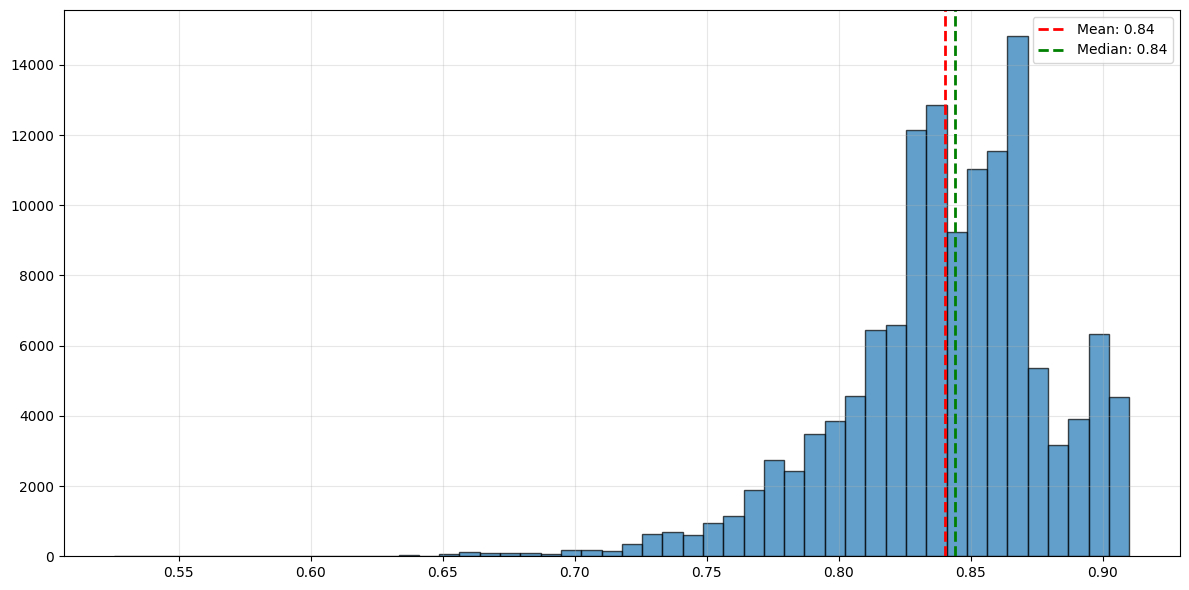

In [66]:
plt.figure(figsize=(12, 6))
plt.hist(series, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(series.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {series.mean():.2f}')
plt.axvline(series.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {series.median():.2f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

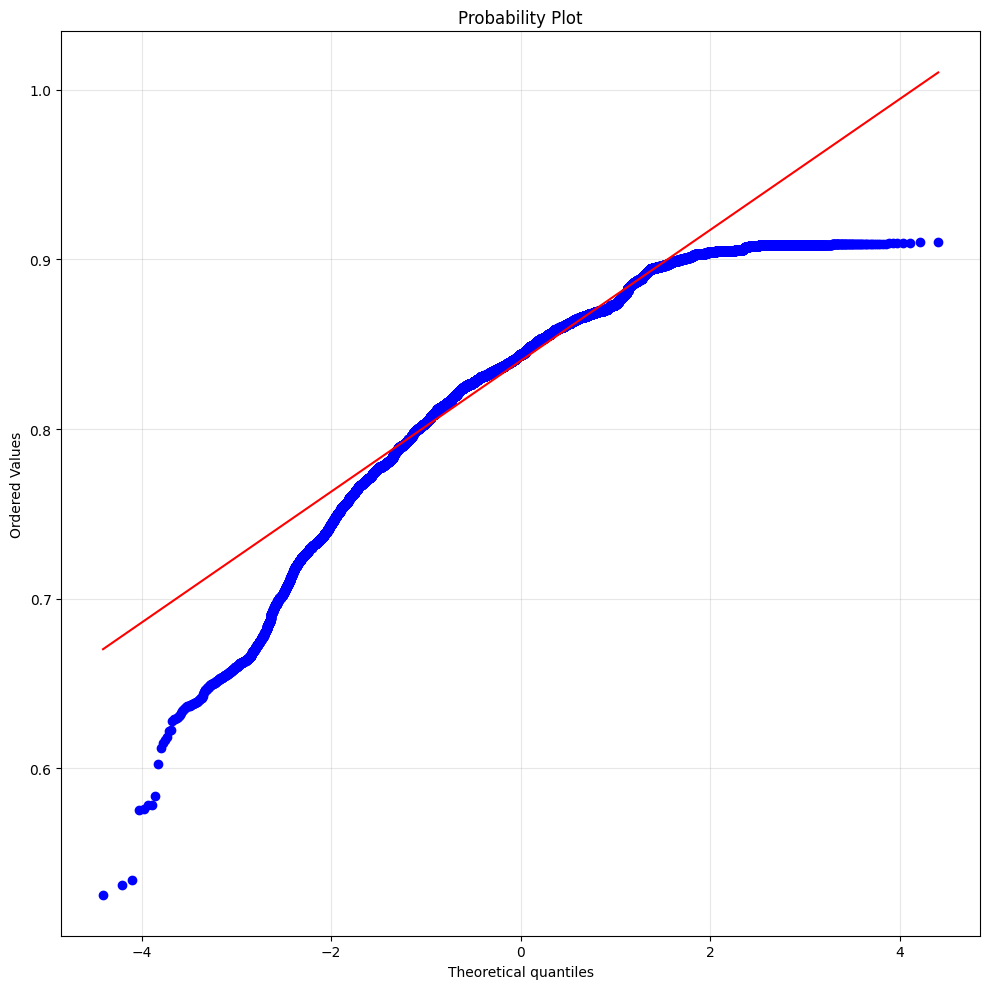

In [69]:
plt.figure(figsize=(10, 10))
stats.probplot(series, dist="norm", plot=plt)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

видна отрицательная ассиметрия, тк концы находятся ниже линии

In [70]:
z_scores = np.abs(stats.zscore(series.dropna()))
z_scores

array([1.98768823, 1.98497803, 1.99158551, ..., 1.7453167 , 1.74768782,
       1.74757778], shape=(132481,))

In [72]:
outliers_zscore = np.where(z_scores > 3)[0]
print(f"{len(outliers_zscore)} выбросов ({len(outliers_zscore)/len(series)*100:.2f}%)")

1278 выбросов (0.96%)


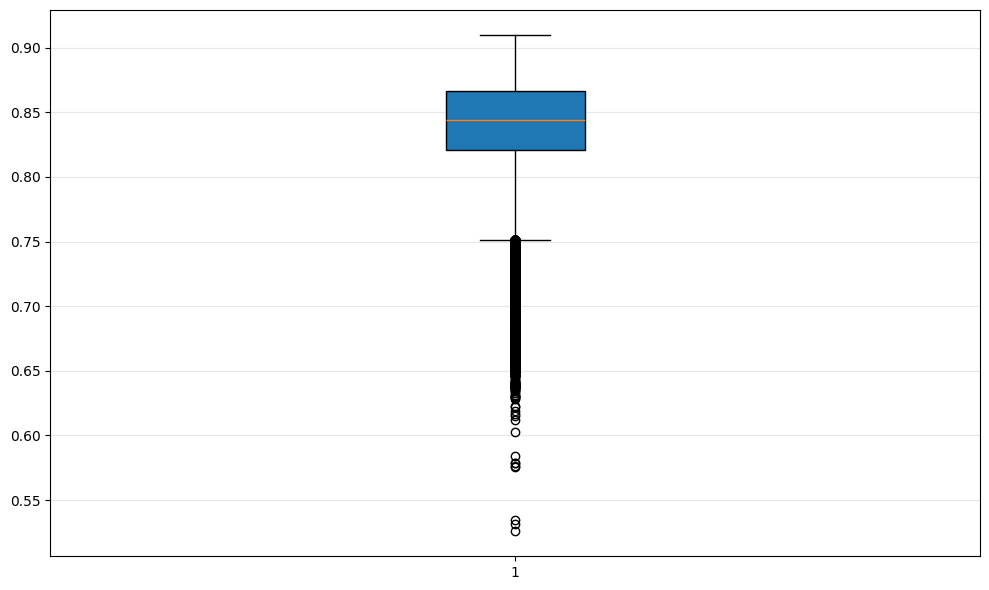

In [79]:
plt.figure(figsize=(10, 6))
box = plt.boxplot(series.dropna(), patch_artist=True)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

присутствует много маленьких выбросов


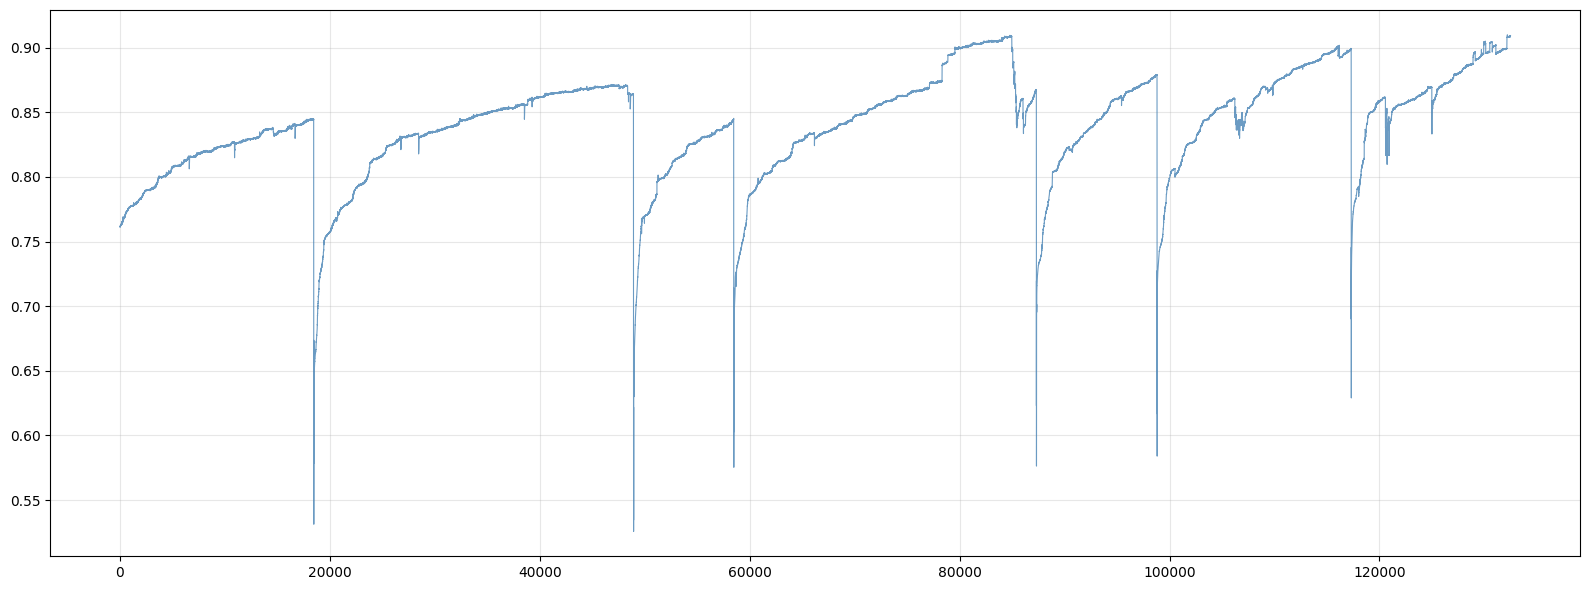

In [82]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(series.values, linewidth=0.8, color='steelblue', alpha=0.8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

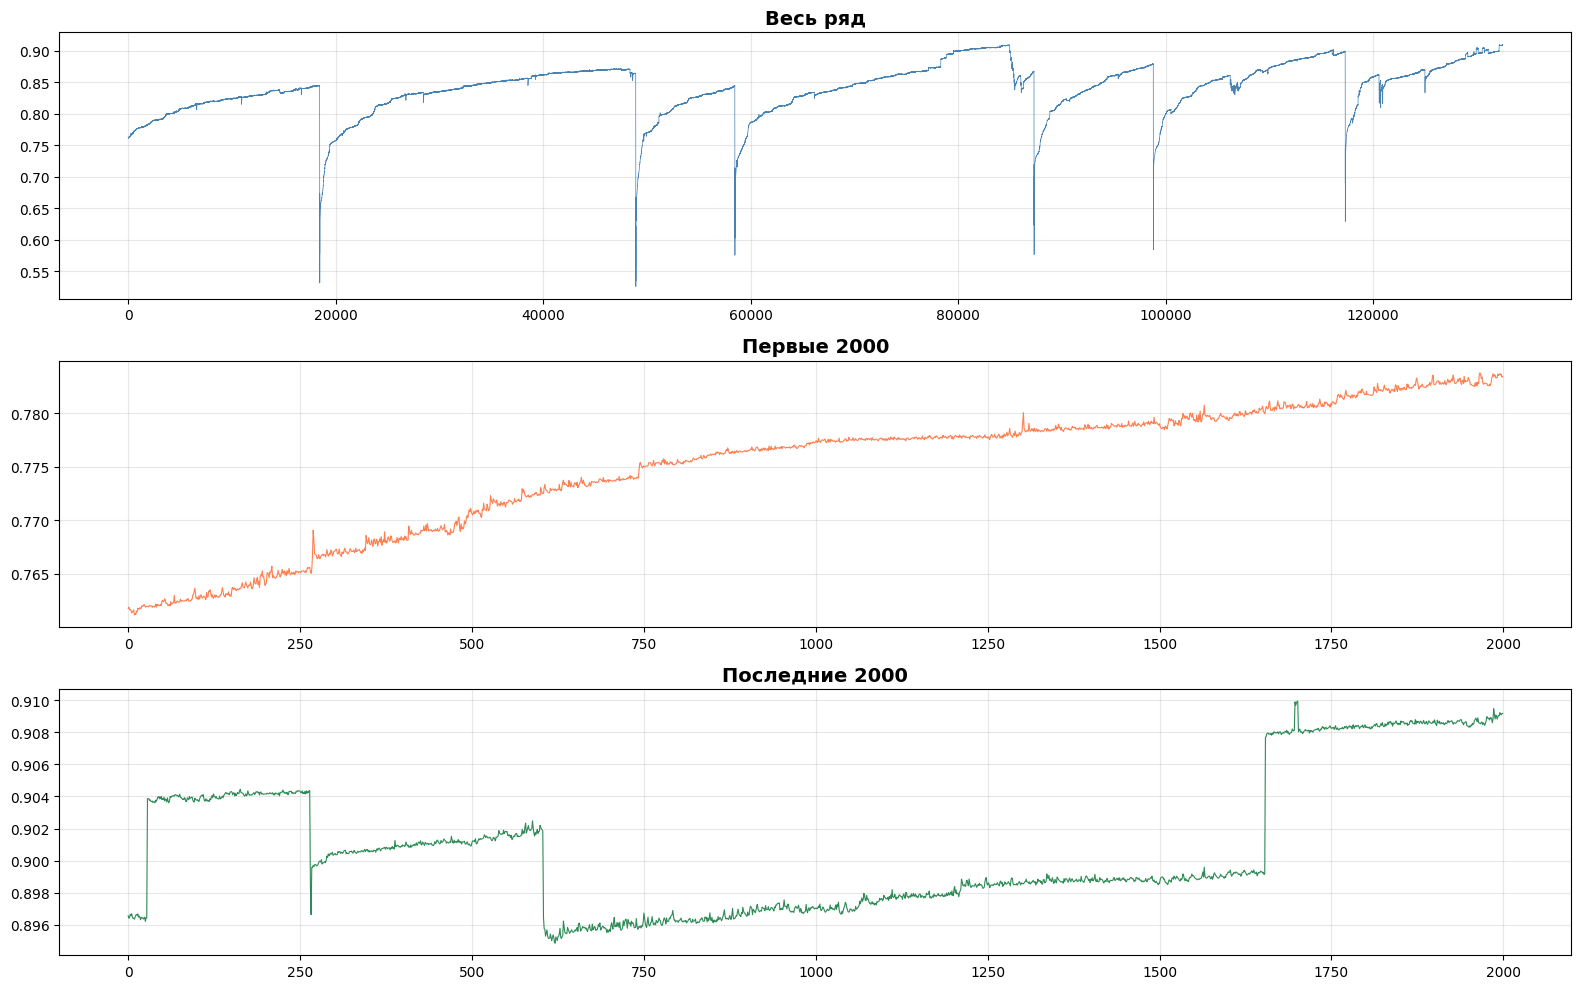

In [84]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10))

axes[0].plot(series.values, linewidth=0.5, color='steelblue')
axes[0].set_title('Весь ряд', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Первые 2000 точек
axes[1].plot(series[:2000].values, linewidth=0.8, color='coral')
axes[1].set_title('Первые 2000', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Последние 2000 точек
axes[2].plot(series[-2000:].values, linewidth=0.8, color='seagreen')
axes[2].set_title('Последние 2000', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [86]:
period = 1440 
series_decomp = series[:43200]
print(f"Декомпозиция на 43200 точках (период = {period} минут = 24 часа)")

Декомпозиция на 43200 точках (период = 1440 минут = 24 часа)


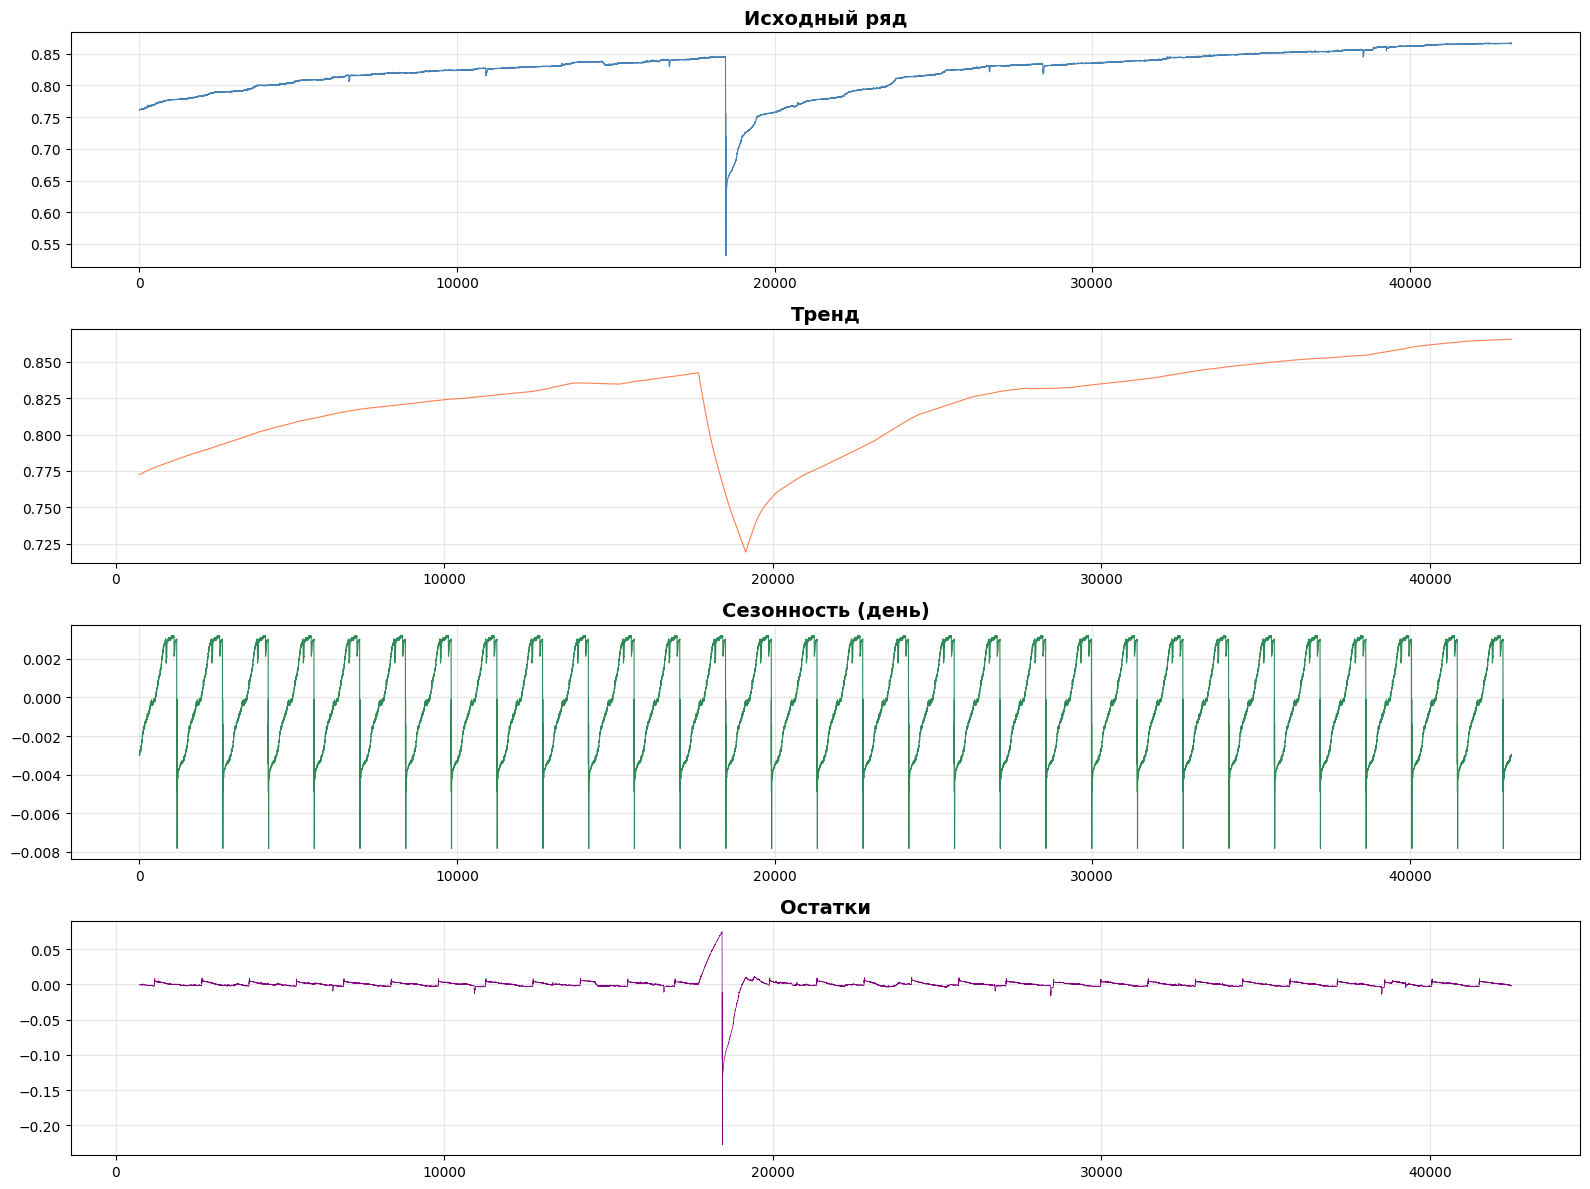

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
try:
    decomposition = seasonal_decompose(series_decomp, model='additive', period=period)
    
    fig, axes = plt.subplots(4, 1, figsize=(16, 12))
    
    axes[0].plot(decomposition.observed, linewidth=0.8, color='steelblue')
    axes[0].set_title('Исходный ряд', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(decomposition.trend, linewidth=0.8, color='coral')
    axes[1].set_title('Тренд', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    axes[2].plot(decomposition.seasonal, linewidth=0.8, color='seagreen')
    axes[2].set_title(f'Сезонность (день)', fontsize=14, fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    
    axes[3].plot(decomposition.resid, linewidth=0.5, color='purple')
    axes[3].set_title('Остатки', fontsize=14, fontweight='bold')

    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"Не удалось выполнить декомпозицию: {e}")
    

In [95]:
from statsmodels.tsa.stattools import acf, pacf

acf_values = acf(series, nlags=10, fft=False)
pacf_values = pacf(series, nlags=10, method='ywm')
acf_values,pacf_values

(array([1.        , 0.99799866, 0.9977867 , 0.99900392, 0.99725785,
        0.9967898 , 0.99741139, 0.99597385, 0.99532636, 0.99546409,
        0.99431508]),
 array([ 1.00000000e+00,  9.97998655e-01,  4.46493086e-01,  6.95884277e-01,
        -3.84209232e-01, -2.02903625e-01, -1.43797339e-01,  1.08674381e-04,
        -4.04983874e-02, -7.39791519e-02,  2.20707288e-02]))

высокая автокорреляция, нет затухания

### СТАТИСТИЧЕСКИЕ ТЕСТЫ

ДИКИ-ФУЛЛЕРА (стационарность)

In [96]:
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(series.dropna())

In [102]:
print(f"Статистика ADF: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print(f"Критические значения:")
for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")

Статистика ADF: -5.4302
p-value: 0.0000
Критические значения:
1%: -3.4304
5%: -2.8616
10%: -2.5668


ряд стационарный, p < 0.05

ШАПИРО-УИЛКА (нормальность остатков)

In [103]:
shapiro_stat, shapiro_p = stats.shapiro(series)

In [105]:
print(f"Статистика Шапиро-Уилка: {shapiro_stat:.4f}")
print(f"p-value: {shapiro_p:.4e}")

Статистика Шапиро-Уилка: 0.9540
p-value: 1.8190e-97


распределение отличается от нормального p < 0.05

ЛЬЮНГА-БОКСА (автокорреляция остатков)

In [109]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_result = acorr_ljungbox(series, lags=[5, 10, 20], return_df=True)
lb_result

,lb_stat,lb_pvalue
5,6.594758e+05,0.0
10,1.316244e+06,0.0
20,2.617422e+06,0.0


везде есть автокореляция

## Генерация признаков

### ЛАГОВЫЕ ПРИЗНАКИ}

In [112]:
df_features = pd.DataFrame(index=series.index)
df_features.head()

""
0
1
2
3
4


In [114]:
for lag in range(1, 31):
    df_features[f'lag_{lag}'] = series.shift(lag)
df_features

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,...,lag_21,lag_22,lag_23,lag_24,lag_25,lag_26,lag_27,lag_28,lag_29,lag_30
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.761748,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.761855,0.761748,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.761594,0.761855,0.761748,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.761656,0.761594,0.761855,0.761748,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132476,0.909046,0.909063,0.908959,0.908830,0.909047,0.909087,0.908833,0.909113,0.909480,0.908853,...,0.908573,0.908437,0.908539,0.908596,0.908484,0.908648,0.908627,0.908536,0.908575,0.908582
132477,0.909234,0.909046,0.909063,0.908959,0.908830,0.909047,0.909087,0.908833,0.909113,0.909480,...,0.908725,0.908573,0.908437,0.908539,0.908596,0.908484,0.908648,0.908627,0.908536,0.908575
132478,0.909155,0.909234,0.909046,0.909063,0.908959,0.908830,0.909047,0.909087,0.908833,0.909113,...,0.908985,0.908725,0.908573,0.908437,0.908539,0.908596,0.908484,0.908648,0.908627,0.908536
132479,0.909096,0.909155,0.909234,0.909046,0.909063,0.908959,0.908830,0.909047,0.909087,0.908833,...,0.908942,0.908985,0.908725,0.908573,0.908437,0.908539,0.908596,0.908484,0.908648,0.908627


In [115]:
seasonal_lags = [60, 120, 180, 240, 300, 360, 720, 1440, 2880]
for lag in seasonal_lags:
    df_features[f'seasonal_lag_{lag}'] = series.shift(lag)
df_features

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,...,lag_30,seasonal_lag_60,seasonal_lag_120,seasonal_lag_180,seasonal_lag_240,seasonal_lag_300,seasonal_lag_360,seasonal_lag_720,seasonal_lag_1440,seasonal_lag_2880
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.761748,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.761855,0.761748,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.761594,0.761855,0.761748,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.761656,0.761594,0.761855,0.761748,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132476,0.909046,0.909063,0.908959,0.908830,0.909047,0.909087,0.908833,0.909113,0.909480,0.908853,...,0.908582,0.908734,0.908616,0.908542,0.908316,0.908092,0.899286,0.898668,0.901562,0.892789
132477,0.909234,0.909046,0.909063,0.908959,0.908830,0.909047,0.909087,0.908833,0.909113,0.909480,...,0.908575,0.908690,0.908693,0.908543,0.908426,0.908126,0.899245,0.898577,0.901437,0.892898
132478,0.909155,0.909234,0.909046,0.909063,0.908959,0.908830,0.909047,0.909087,0.908833,0.909113,...,0.908536,0.908762,0.908674,0.908387,0.908195,0.909910,0.899409,0.898520,0.901582,0.892806
132479,0.909096,0.909155,0.909234,0.909046,0.909063,0.908959,0.908830,0.909047,0.909087,0.908833,...,0.908627,0.908806,0.908556,0.908357,0.908211,0.909693,0.899283,0.898556,0.901323,0.893131


In [116]:
for lag in [1, 2, 3, 5, 10]:
    df_features[f'diff_{lag}'] = series.diff(lag)
df_features.columns

Index(['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8',
       'lag_9', 'lag_10', 'lag_11', 'lag_12', 'lag_13', 'lag_14', 'lag_15',
       'lag_16', 'lag_17', 'lag_18', 'lag_19', 'lag_20', 'lag_21', 'lag_22',
       'lag_23', 'lag_24', 'lag_25', 'lag_26', 'lag_27', 'lag_28', 'lag_29',
       'lag_30', 'seasonal_lag_60', 'seasonal_lag_120', 'seasonal_lag_180',
       'seasonal_lag_240', 'seasonal_lag_300', 'seasonal_lag_360',
       'seasonal_lag_720', 'seasonal_lag_1440', 'seasonal_lag_2880', 'diff_1',
       'diff_2', 'diff_3', 'diff_5', 'diff_10'],
      dtype='str')

In [118]:
df_features['log_lag_1'] = np.log1p(series.shift(1).clip(lower=0))
df_features['log_lag_1']

0              NaN
1         0.566306
2         0.566367
3         0.566219
4         0.566254
            ...   
132476    0.646603
132477    0.646702
132478    0.646661
132479    0.646630
132480    0.646679
Name: log_lag_1, Length: 132481, dtype: float64

In [121]:
print(f"Создано {len([c for c in df_features.columns if 'lag' in c or 'diff' in c or 'log' in c])} лаговых признаков")

Создано 45 лаговых признаков


### СКОЛЬЗЯЩИЕ СТАТИСТИКИ

In [122]:
windows = [3, 5, 7, 10, 14, 21, 30, 60, 120, 240]

In [123]:
for window in windows:
    df_features[f'rolling_mean_{window}'] = series.rolling(window).mean()
    df_features[f'rolling_median_{window}'] = series.rolling(window).median()

    # Разброс
    df_features[f'rolling_std_{window}'] = series.rolling(window).std()
    df_features[f'rolling_min_{window}'] = series.rolling(window).min()
    df_features[f'rolling_max_{window}'] = series.rolling(window).max()
    df_features[f'rolling_range_{window}'] = df_features[f'rolling_max_{window}'] - df_features[f'rolling_min_{window}']
        
    # Форма распределения
    df_features[f'rolling_skew_{window}'] = series.rolling(window).skew()
    df_features[f'rolling_kurt_{window}'] = series.rolling(window).kurt()
    
    # Квантили
    df_features[f'rolling_q25_{window}'] = series.rolling(window).quantile(0.25)
    df_features[f'rolling_q75_{window}'] = series.rolling(window).quantile(0.75)
    df_features[f'rolling_iqr_{window}'] = df_features[f'rolling_q75_{window}'] - df_features[f'rolling_q25_{window}']
        
        
print(f" Создано скользящих статистик: {len(windows)*11}")

 Создано скользящих статистик: 110


### ЭКСПОНЕНЦИАЛЬНЫЕ СРЕДНИЕ

In [126]:
alphas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for alpha in alphas:
    df_features[f'ema_{alpha}'] = series.ewm(alpha=alpha, adjust=False).mean()
    
    # Двойная EMA
    ema1 = series.ewm(alpha=alpha, adjust=False).mean()
    ema2 = ema1.ewm(alpha=alpha, adjust=False).mean()
    df_features[f'dema_{alpha}'] = 2 * ema1 - ema2

    # EMA3: EMA от EMA2
    ema3 = ema2.ewm(alpha=alpha, adjust=False).mean()
    
    # TEMA формула: 3*EMA1 - 3*EMA2 + EMA3
    tema = 3 * ema1 - 3 * ema2 + ema3
    df_features[f'tema_{alpha}'] = tema

print(f"Создано {len(alphas)*3} EMA признаков")


Создано 27 EMA признаков


In [128]:
df_features.columns.shape

(182,)

### ТЕХНИЧЕСКИЕ ИНДИКАТОРЫ

In [129]:
# RSI (Relative Strength Index)
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rsi = 100 - (100 / (1 + gain / loss))
    return rsi

In [130]:
df_features['rsi_14'] = compute_rsi(series, 14)
df_features['rsi_21'] = compute_rsi(series, 21)

In [132]:
def stochastic_oscillator(df_features, series, period=14, smooth_k=3, smooth_d=3):
    # Расчет минимумов и максимумов за период
    rolling_min = series.rolling(window=period).min()
    rolling_max = series.rolling(window=period).max()
    
    #  %K
    k = 100 * (series - rolling_min) / (rolling_max - rolling_min)
    
    # %D 
    d = k.rolling(window=smooth_k).mean()
    
    df_features[f'stoch_k_{period}'] = k
    df_features[f'stoch_d_{period}'] = d
    
    return df_features

In [133]:
stochastic_periods = [10, 14, 21]  

for period in stochastic_periods:
    df_features = stochastic_oscillator(df_features, series, period=period, smooth_k=3, smooth_d=3)
    

In [135]:
# Williams %R
for period in [10, 14, 20]:
    highest_high = series.rolling(window=period).max()
    lowest_low = series.rolling(window=period).min()
    df_features[f'williams_r_{period}'] = -100 * (highest_high - series) / (highest_high - lowest_low)

In [134]:
# ROC (Rate of Change)
for period in [5, 10, 20, 30]:
    df_features[f'roc_{period}'] = (series - series.shift(period)) / series.shift(period) * 100

In [ ]:
# Momentum
for period in [5, 10, 20, 30]:
    df_features[f'momentum_{period}'] = series - series.shift(period)

In [137]:
def macd(df_features, series, fast=12, slow=26, signal=9):
    """MACD с настраиваемыми параметрами"""
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram = macd_line - signal_line
    
    df_features[f'macd_{fast}_{slow}'] = macd_line
    df_features[f'macd_signal_{fast}_{slow}'] = signal_line
    df_features[f'macd_hist_{fast}_{slow}'] = histogram
    
    return df_features

In [138]:
macd_configs = [(12, 26, 9), (10, 20, 5), (20, 50, 10)]
for fast, slow, signal in macd_configs:
    df_features = macd(df_features, series, fast, slow, signal)
print(f"MACD: {len(macd_configs)} наборов параметров × 3 = {len(macd_configs)*3} признаков")

MACD: 3 наборов параметров × 3 = 9 признаков


In [139]:
df_features.columns

Index(['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8',
       'lag_9', 'lag_10',
       ...
       'momentum_30', 'macd_12_26', 'macd_signal_12_26', 'macd_hist_12_26',
       'macd_10_20', 'macd_signal_10_20', 'macd_hist_10_20', 'macd_20_50',
       'macd_signal_20_50', 'macd_hist_20_50'],
      dtype='str', length=210)

In [141]:
# Parabolic SAR 
def parabolic_sar(df_features, series, acceleration=0.02, maximum=0.2):
    sar = series.copy()
    trend_up = True
    ep = series.iloc[0]  # extreme point
    acc = acceleration
    
    for i in range(1, len(series)):
        if trend_up:
            sar.iloc[i] = sar.iloc[i-1] + acc * (ep - sar.iloc[i-1])
            
            if series.iloc[i] > ep:
                ep = series.iloc[i]
                acc = min(acc + acceleration, maximum)
            
            if series.iloc[i] < sar.iloc[i]:
                trend_up = False
                sar.iloc[i] = ep
                ep = series.iloc[i]
                acc = acceleration
        else:
            sar.iloc[i] = sar.iloc[i-1] + acc * (ep - sar.iloc[i-1])
            
            if series.iloc[i] < ep:
                ep = series.iloc[i]
                acc = min(acc + acceleration, maximum)
            
            if series.iloc[i] > sar.iloc[i]:
                trend_up = True
                sar.iloc[i] = ep
                ep = series.iloc[i]
                acc = acceleration
    
    df_features['parabolic_sar'] = sar
    
    return df_features

df_features = parabolic_sar(df_features, series)


In [143]:
# ADX (Average Directional Index) 
def adx(df_features, series, period=14):
    # Расчет направленных движений
    high = series  # для одномерного ряда используем series как high
    low = series   # и как low
    prev_high = high.shift(1)
    prev_low = low.shift(1)
    
    # Plus DM и Minus DM
    plus_dm = ((high - prev_high) > (prev_low - low)) & (high - prev_high > 0)
    plus_dm = plus_dm.astype(float) * (high - prev_high)
    minus_dm = ((prev_low - low) > (high - prev_high)) & (prev_low - low > 0)
    minus_dm = minus_dm.astype(float) * (prev_low - low)
    
    # True Range
    true_range = series.diff().abs()
    
    # Сглаживание
    atr = true_range.rolling(window=period).mean()
    smooth_plus_dm = plus_dm.rolling(window=period).mean()
    smooth_minus_dm = minus_dm.rolling(window=period).mean()
    
    # Directional Indicators
    plus_di = 100 * smooth_plus_dm / atr
    minus_di = 100 * smooth_minus_dm / atr
    
    # DX и ADX
    dx = 100 * abs(plus_di - minus_di) / (plus_di + minus_di)
    adx = dx.rolling(window=period).mean()
    
    df_features[f'adx_{period}'] = adx
    
    return df_features

for period in [14, 21]:
    df_features = adx(df_features, series, period)

In [145]:
def bollinger_bands(df_features, series, period=20, num_std=2):
    sma = series.rolling(window=period).mean()
    std = series.rolling(window=period).std()
    
    upper = sma + num_std * std
    lower = sma - num_std * std
    
    df_features[f'bb_upper_{period}_{num_std}'] = upper
    df_features[f'bb_lower_{period}_{num_std}'] = lower
    df_features[f'bb_width_{period}_{num_std}'] = (upper - lower) / sma
    df_features[f'bb_position_{period}_{num_std}'] = (series - lower) / (upper - lower)
    
    return df_features

In [146]:
bb_configs = [(10, 2), (20, 2), (20, 3)]
for period, num_std in bb_configs:
    df_features = bollinger_bands(df_features, series, period, num_std)

In [147]:
# ATR
def atr(df_features, series, period=14):
    atr = series.diff().abs().rolling(window=period).mean()
    
    df_features[f'atr_{period}'] = atr
        
    return df_features

for period in [7, 14, 21, 30]:
    df_features = atr(df_features, series, period)

In [148]:
# ---------- Volatility Ratio ----------
def volatility_ratio(df_features, series, short_period=10, long_period=30):
    short_vol = series.diff().abs().rolling(window=short_period).mean()
    long_vol = series.diff().abs().rolling(window=long_period).mean()
    
    vol_ratio = short_vol / long_vol
    
    df_features[f'volatility_ratio_{short_period}_{long_period}'] = vol_ratio
    
    return df_features

vol_configs = [(5, 20), (10, 30), (20, 50)]
for short_p, long_p in vol_configs:
    df_features = volatility_ratio(df_features, series, short_p, long_p)

In [150]:
if 'volume' in train_df.columns or 'Volume' in train_df.columns:
    print('yes')

In [151]:
if 'timestamp_min' in train_df.columns:
    print("\n1️⃣ Используем timestamp_min из данных...")


1️⃣ Используем timestamp_min из данных...


In [167]:
df_features['datetime'] = pd.to_datetime('2020-01-01 00:00:00') + \
                              pd.to_timedelta(train_df['timestamp_min'], unit='m')
    
# Базовые компоненты (оставляем для непрерывных признаков)
df_features['hour'] = df_features['datetime'].dt.hour
df_features['day_of_month'] = df_features['datetime'].dt.day
df_features['month'] = df_features['datetime'].dt.month
df_features['day_of_week'] = df_features['datetime'].dt.dayofweek  # 0=пн, 6=вс
df_features['day_of_year'] = df_features['datetime'].dt.dayofyear  # 0=пн, 6=вс
df_features['week_of_year'] = df_features['datetime'].dt.isocalendar().week.astype(int)
df_features['quarter'] = df_features['datetime'].dt.quarter

for month in range(1, 13):
    df_features[f'month_{month}'] = (df_features['month'] == month).astype(int)


days = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
for i, day_name in enumerate(days):
    df_features[f'day_{day_name}'] = (df_features['day_of_week'] == i).astype(int)


cols_to_drop = ['month', 'day_of_week']
existing_drop = [c for c in cols_to_drop if c in df_features.columns]
df_features = df_features.drop(columns=existing_drop)


In [169]:
df_features['hour_sin'] = np.sin(2 * np.pi * df_features['hour'] / 24)
df_features['hour_cos'] = np.cos(2 * np.pi * df_features['hour'] / 24)

df_features['dayweek_sin'] = np.sin(2 * np.pi * df_features['day_of_month'] / 7)
df_features['dayweek_cos'] = np.cos(2 * np.pi * df_features['day_of_month'] / 7)


df_features['dayyear_sin'] = np.sin(2 * np.pi * df_features['day_of_year'] / 365)
df_features['dayyear_cos'] = np.cos(2 * np.pi * df_features['day_of_year'] / 365)


In [172]:
df_features['is_weekend'] = (df_features['day_saturday'] + df_features['day_sunday']).astype(int)

df_features['is_workday'] = (1 - df_features['is_weekend']).astype(int)

df_features['is_monday'] = df_features['day_monday']

df_features['is_friday'] = df_features['day_friday']


### СТАТИСТИЧЕСКИЕ И МАТЕМАТИЧЕСКИЕ ПРИЗНАКИ

In [173]:
from scipy.signal import find_peaks


In [174]:

def autocorrelation(df_features, series,lags):    
    for lag in lags:
        if len(series) > lag * 2:
            # Простая автокорреляция
            autocorr = series.autocorr(lag=lag)
            df_features[f'autocorr_lag_{lag}'] = autocorr
            
            
            series_lagged = series.shift(lag)
            partial_corr = series.corr(series_lagged)
            df_features[f'partial_autocorr_{lag}'] = partial_corr
        
    return df_features

lags = [1, 2, 3, 7, 14, 30]
df_features = autocorrelation(df_features, series,lags)


In [179]:
def hurst_exponent(series):
    series = np.array(series.dropna())
    if len(series) < 50:
        return 0.5
    
    lags = range(10, min(50, len(series)//4))
    tau = []
    
    for lag in lags:
        diff = np.diff(series[::lag]) if lag > 0 else series
        if len(diff) > 1:
            std_diff = np.std(diff)
            if std_diff > 0:
                tau.append(np.std(diff))
    
    if len(tau) < 2:
        return 0.5
    
    try:
        hurst = np.polyfit(np.log(lags[:len(tau)]), np.log(tau), 1)[0]
        return max(0, min(1, hurst))
    except:
        return 0.5

df_features['hurst_exponent'] = hurst_exponent(series)

In [185]:
def fractal_dimension(series):
    series = np.array(series.dropna())
    n = len(series)
    
    if n < 3:
        return np.nan
    
    # Общая длина кривой 
    L = np.sum(np.sqrt(1 + np.diff(series) ** 2))
    
    # Диаметр 
    distances = np.sqrt((np.arange(n) - 0) ** 2 + (series - series[0]) ** 2)
    d = np.max(distances)
    
    if d <= 0:
        return np.nan
    
    return np.log(L) / np.log(d)

df_features['fractal_dim'] = fractal_dimension(series)

In [181]:
def dfa(series, min_window=10, max_window=None, order=1):
    series = np.array(series.dropna())
    N = len(series)
    
    if N < 100:
        return np.nan
    
    if max_window is None:
        max_window = N // 4
    
    # Интегрируем ряд
    mean = np.mean(series)
    y = np.cumsum(series - mean)
    
    # Логарифмически распределенные окна
    windows = np.unique(np.logspace(np.log10(min_window), np.log10(max_window), 20, dtype=int))
    windows = windows[windows < N//2]
    
    fluctuations = []
    
    for w in windows:
        # Количество окон
        n_windows = N // w
        
        # Сумма квадратов отклонений
        rms = 0
        
        for i in range(n_windows):
            start = i * w
            end = start + w
            
            if end > N:
                break
            
            # Убираем тренд
            x = np.arange(w)
            y_window = y[start:end]
            
            # Полиномиальная регрессия (порядок order)
            coefs = np.polyfit(x, y_window, order)
            trend = np.polyval(coefs, x)
            
            # Детрендирование
            detrended = y_window - trend
            
            rms += np.sum(detrended ** 2)
        
        # Среднеквадратичная флуктуация
        rms = np.sqrt(rms / (n_windows * w))
        fluctuations.append(rms)
    
    if len(windows) < 5:
        return np.nan
    
    alpha = np.polyfit(np.log(windows[:len(fluctuations)]), np.log(fluctuations), 1)[0]
    
    return alpha


df_features['dfa_alpha'] = dfa(series)


In [186]:
def correlation_dimension(series, m=3, r_ratio=0.2):
    series = np.array(series.dropna())
    N = len(series)
    
    # Вложения в m-мерное пространство
    embeddings = np.array([series[i:i+m] for i in range(N - m + 1)])
    if len(embeddings) < 10:
        return np.nan
    
    # Вычисляем расстояния между точками
    r = r_ratio * np.std(series)
    
    # Бинарная матрица близост
    C = 0
    n_pairs = 0
    
    # Сэмплируем для ускорения
    sample_size = min(500, len(embeddings))
    indices = np.random.choice(len(embeddings), sample_size, replace=False)
    
    for i in indices:
        for j in indices:
            if i != j:
                dist = np.max(np.abs(embeddings[i] - embeddings[j]))
                if dist < r:
                    C += 1
                n_pairs += 1
    
    if n_pairs == 0:
        return np.nan
    
    C = C / n_pairs
    
    if C <= 0:
        return np.nan
    
    return -np.log(C) / np.log(r)

df_features['correlation_dim'] = correlation_dimension(series)

In [187]:
def lyapunov_exponent(series, n_neighbors=3, max_steps=20):
    series = np.array(series.dropna())
    N = len(series)
    
    if N < 200:
        return np.nan
    
    # Поиск ближайших соседей
    divergences = []
    
    # опорные точки
    n_ref = min(100, N // 10)
    ref_indices = np.linspace(0, N - max_steps - 1, n_ref, dtype=int)
    
    for i in ref_indices:
        # Ищем ближайшего соседа
        min_dist = float('inf')
        nearest_j = -1
        
        for j in range(N - max_steps - 1):
            if abs(j - i) > 10:  # не тот же период
                dist = abs(series[i] - series[j])
                if dist < min_dist:
                    min_dist = dist
                    nearest_j = j
        
        if nearest_j == -1:
            continue
        
        # Следим за расхождением
        for step in range(1, max_steps):
            if i + step < N and nearest_j + step < N:
                current_dist = abs(series[i + step] - series[nearest_j + step])
                if current_dist > 0:
                    divergences.append(np.log(current_dist / min_dist) / step)
    
    if not divergences:
        return 0
    
    return np.mean(divergences)

df_features['lyapunov_exponent'] = lyapunov_exponent(series)


In [188]:
def recurrence_rate(series, threshold=0.2, min_n=100):
    series = np.array(series.dropna())
    N = len(series)
    
    if N < min_n:
        return np.nan
    
    eps = threshold * np.std(series)
    
    # Рекуррентная матрица
    sample_size = min(300, N)
    indices = np.linspace(0, N-1, sample_size, dtype=int)
    
    recurrences = 0
    total_pairs = 0
    
    for i in range(len(indices)):
        for j in range(i+1, len(indices)):
            if abs(series[indices[i]] - series[indices[j]]) < eps:
                recurrences += 1
            total_pairs += 1
    
    if total_pairs == 0:
        return 0
    
    return recurrences / total_pairs


df_features['rqa_recurrence_rate'] = recurrence_rate(series)


In [189]:
for window in [10, 20, 30, 60, 120, 240]:
    if len(series) > window:
        rolling_mean = series.rolling(window).mean()
        rolling_std = series.rolling(window).std()
        df_features[f'cv_{window}'] = rolling_std / rolling_mean


In [190]:
def concentration_index(series):
    series = np.array(series.dropna())
    if len(series) < 10:
        return np.nan
    
    # Сортируем
    sorted_vals = np.sort(series)
    n = len(sorted_vals)
    
    # Индекс
    numerator = np.sum((2 * np.arange(1, n+1) - n - 1) * sorted_vals)
    denominator = n * np.sum(sorted_vals)
    
    if denominator == 0:
        return 0
    
    return numerator / denominator

df_features['concentration_index'] = concentration_index(series)

In [191]:
def zero_crossings(series):
    series = np.array(series.dropna())
    if len(series) < 2:
        return 0
    
    # Центрируем
    centered = series - np.mean(series)
    
    # Считаем пересечения
    crossings = np.sum(np.diff(np.sign(centered)) != 0)
    
    return crossings

def zero_crossings_rate(series, window=100):
    if len(series) < window:
        return 0
    
    crossings = zero_crossings(series)
    return crossings / len(series)

df_features['zero_crossings'] = zero_crossings(series)
df_features['zero_crossings_rate'] = zero_crossings_rate(series)

In [192]:
def count_local_extrema(series):
    series = np.array(series.dropna())
    if len(series) < 3:
        return 0
    
    # Пики
    peaks = np.sum((series[1:-1] > series[:-2]) & (series[1:-1] > series[2:]))
    
    # Впадины
    troughs = np.sum((series[1:-1] < series[:-2]) & (series[1:-1] < series[2:]))
    
    return peaks + troughs

def extrema_rate(series, window=100):
    if len(series) < window:
        return 0
    
    n_extrema = count_local_extrema(series)
    return n_extrema / len(series)

df_features['local_extrema_count'] = count_local_extrema(series)
df_features['local_extrema_rate'] = extrema_rate(series)

In [193]:
for window in [10, 20, 50, 100, 200]:
    if len(series) > window:
        df_features[f'energy_{window}'] = (series ** 2).rolling(window).sum()


In [194]:
df_features.shape

(132481, 301)

### ЧАСТОТНЫЕ ПРИЗНАКИ

In [195]:
def dft_coefficients(series, n_coeffs=5):
    series = np.array(series.dropna())
    if len(series) < 2 * n_coeffs:
        return [0] * n_coeffs
    
    # FFT
    fft_vals = np.fft.fft(series)
    fft_abs = np.abs(fft_vals[:len(fft_vals)//2])
    
    # Нормализуем
    fft_abs = fft_abs / np.sum(fft_abs)
    
    # Берем первые коэффициенты
    return fft_abs[:n_coeffs].tolist()

# Добавляем DFT коэффициенты
dft_coeffs = dft_coefficients(series)
for i, coeff in enumerate(dft_coeffs[:10]):
    df_features[f'dft_coeff_{i+1}'] = coeff

In [200]:
df_features['dft_coeff_2']

0         0.005604
1         0.005604
2         0.005604
3         0.005604
4         0.005604
            ...   
132476    0.005604
132477    0.005604
132478    0.005604
132479    0.005604
132480    0.005604
Name: dft_coeff_2, Length: 132481, dtype: float64

In [196]:
def power_spectral_density(series):
    series = np.array(series.dropna())
    
    fft_vals = np.fft.fft(series)
    psd = np.abs(fft_vals) ** 2
    
    return np.sum(psd) / len(series)

df_features['psd_total'] = power_spectral_density(series)


In [201]:
def dominant_frequencies(series, n_freqs=3):
    series = np.array(series.dropna())
    
    fft_vals = np.fft.fft(series)
    fft_abs = np.abs(fft_vals[:len(fft_vals)//2])
    freqs = np.fft.fftfreq(len(series))[:len(series)//2]
    
    # Топ частот
    if len(fft_abs) > n_freqs:
        top_idx = np.argsort(fft_abs)[-n_freqs:]
        return freqs[top_idx].tolist()
    
    return [0] * n_freqs

dom_freqs = dominant_frequencies(series)
for i, freq in enumerate(dom_freqs[:3]):
    df_features[f'dominant_freq_{i+1}'] = freq

In [212]:
def spectral_centroid(series):
    """Спектральный центроид"""
    series = to_array(series)
    
    if len(series) < 10:
        return 0.0
    
    fft_vals = np.fft.fft(series)
    fft_abs = np.abs(fft_vals[:len(fft_vals)//2])
    freqs = np.fft.fftfreq(len(series))[:len(series)//2]
    
    if np.sum(fft_abs) == 0:
        return 0.0
    
    return float(np.sum(freqs * fft_abs) / np.sum(fft_abs))

In [213]:
def to_array(data):
    """Преобразует входные данные в numpy array"""
    if isinstance(data, pd.Series):
        return data.dropna().values
    elif isinstance(data, np.ndarray):
        return data[~np.isnan(data)]
    else:
        data = np.array(data)
        return data[~np.isnan(data)]

In [215]:
def spectral_variance(series):
    series = to_array(series)
    
    if len(series) < 10:
        return 0
    
    fft_vals = np.fft.fft(series)
    fft_abs = np.abs(fft_vals[:len(fft_vals)//2])
    freqs = np.fft.fftfreq(len(series))[:len(series)//2]
    
    centroid = spectral_centroid(series)
    total = np.sum(fft_abs)
    
    if total == 0:
        return 0
    
    variance = np.sum(((freqs - centroid) ** 2) * fft_abs) / total
    return variance

df_features['spectral_variance'] = spectral_variance(series)


In [216]:
def spectral_skewness(series):
    """Спектральная асимметрия"""
    series = to_array(series)
    
    if len(series) < 10:
        return 0.0
    
    fft_vals = np.fft.fft(series)
    fft_abs = np.abs(fft_vals[:len(fft_vals)//2])
    freqs = np.fft.fftfreq(len(series))[:len(series)//2]
    
    centroid = spectral_centroid(series)
    variance = spectral_variance(series)
    total = np.sum(fft_abs)
    
    if total == 0 or variance == 0:
        return 0.0
    
    skewness = np.sum(((freqs - centroid) ** 3) * fft_abs) / (total * variance ** 1.5)
    return float(skewness)

In [ ]:
def spectral_kurtosis(series):
    series = to_array(series)
    
    if len(series) < 10:
        return 0.0
    
    fft_vals = np.fft.fft(series)
    fft_abs = np.abs(fft_vals[:len(fft_vals)//2])
    freqs = np.fft.fftfreq(len(series))[:len(series)//2]
    
    centroid = spectral_centroid(series)
    variance = spectral_variance(series)
    total = np.sum(fft_abs)
    
    if total == 0 or variance == 0:
        return 0.0
    
    kurtosis = np.sum(((freqs - centroid) ** 4) * fft_abs) / (total * variance ** 2) - 3
    return float(kurtosis)


In [219]:
def spectral_entropy(series, normalize=True):
    series = to_array(series)
    
    if len(series) < 10:
        return 0.0
    
    fft_vals = np.fft.fft(series)
    psd = np.abs(fft_vals) ** 2
    psd = psd / np.sum(psd)
    
    psd = psd[psd > 0]
    
    if len(psd) == 0:
        return 0.0
    
    entropy = -np.sum(psd * np.log2(psd))
    
    if normalize:
        entropy = entropy / np.log2(len(psd))
    
    return float(entropy)

In [218]:
df_features['spectral_skewness'] = spectral_skewness(series)
df_features['spectral_kurtosis'] = spectral_kurtosis(series)
df_features['spectral_entropy'] = spectral_entropy(series)

In [226]:
import pywt
from scipy.fft import dct


In [225]:
def wavelet_decomposition(series, wavelet='db4', level=4):
    series = np.array(series.dropna())
    
    if len(series) < 2**level:
        level = max(1, int(np.log2(len(series))) - 1)
    
    try:
        # Вейвлет-разложение
        coeffs = pywt.wavedec(series, wavelet, level=level)
        
        # cA - аппроксимирующие коэффициенты 
        # cD - детализирующие коэффициенты 
        cA = coeffs[0]  
        cD = coeffs[1:] 
        
        return cA, cD, coeffs
    except:
        return None, None, None

def wavelet_energy(coeffs):
    """Энергия вейвлет-коэффициентов по масштабам"""
    if coeffs is None:
        return []
    
    energies = []
    for i, coeff in enumerate(coeffs):
        energy = np.sum(coeff ** 2)
        energies.append(energy)
    
    # Нормализуем
    total_energy = sum(energies)
    if total_energy > 0:
        energies = [e / total_energy for e in energies]
    
    return energies

def wavelet_entropy(coeffs):
    """Энтропия вейвлет-коэффициентов"""
    energies = wavelet_energy(coeffs)
    
    if not energies:
        return 0
    
    energies = [e for e in energies if e > 0]
    if not energies:
        return 0
    
    entropy = -np.sum(energies * np.log2(energies))
    return entropy

# Применяем вейвлет-преобразование
wavelet_name = 'db4'  # Daubechies 4
level = 3

cA, cD, coeffs = wavelet_decomposition(series, wavelet=wavelet_name, level=level)

if cA is not None:
    df_features['wavelet_energy_total'] = np.sum([np.sum(c**2) for c in coeffs])
    df_features['wavelet_entropy'] = wavelet_entropy(coeffs)
    
    energies = wavelet_energy(coeffs)
    for i, energy in enumerate(energies[:4]):
        df_features[f'wavelet_energy_scale_{i}'] = energy
    
    for i, cd in enumerate(cD[:3]):
        if len(cd) > 0:
            df_features[f'wavelet_cd_{i+1}_mean'] = np.mean(cd)
            df_features[f'wavelet_cd_{i+1}_std'] = np.std(cd)
            df_features[f'wavelet_cd_{i+1}_max'] = np.max(np.abs(cd))
    



In [227]:
def dct_coefficients(series, n_coeffs=20):
    series = np.array(series.dropna())
    if len(series) < n_coeffs:
        n_coeffs = len(series) // 2
    
    # DCT
    dct_vals = dct(series, type=2, norm='ortho')
    
    # Берем первые коэффициенты
    return dct_vals[:n_coeffs]

dct_coeffs = dct_coefficients(series, n_coeffs=10)

for i, coeff in enumerate(dct_coeffs[:10]):
    df_features[f'dct_coeff_{i+1}'] = coeff

In [230]:
import librosa

In [233]:
def mfcc_features(series, n_mfcc=13):
    """Мел-частотные кепстральные коэффициенты"""
    try:
        series = np.array(series.dropna())
        
        # Нормализуем
        series = (series - np.mean(series)) / (np.std(series) + 1e-8)
        
        # MFCC
        mfcc = librosa.feature.mfcc(y=series, sr=1, n_mfcc=n_mfcc)
        
        # Берем среднее по времени
        return np.mean(mfcc, axis=1)
    except ImportError:
        return np.zeros(n_mfcc)

mfcc_vals = mfcc_features(series, n_mfcc=13)

for i, val in enumerate(mfcc_vals[:13]):
    df_features[f'mfcc_{i+1}'] = val


In [234]:
ma_pairs = [(5, 20), (10, 30), (20, 50), (30, 100)]
for short_w, long_w in ma_pairs:
    if len(series) > long_w:
        ma_short = series.rolling(short_w).mean()
        ma_long = series.rolling(long_w).mean()
        df_features[f'ma_ratio_{short_w}_{long_w}'] = ma_short / ma_long
        df_features[f'ma_diff_{short_w}_{long_w}'] = ma_short - ma_long

In [235]:
for window in [10, 20, 30, 50]:
    if len(series) > window:
        ma = series.rolling(window).mean()
        df_features[f'distance_to_ma_{window}'] = (series - ma) / ma
        df_features[f'abs_distance_to_ma_{window}'] = np.abs(series - ma)

In [236]:
if 'rsi_14' in df_features.columns and 'macd' in df_features.columns:
    df_features['rsi_macd_composite'] = (df_features['rsi_14'] / 100) * (1 + df_features['macd'] / df_features['macd'].std())

if 'bb_position_20' in df_features.columns and 'stoch_k_14' in df_features.columns:
    df_features['bb_stoch_composite'] = (df_features['bb_position_20'] + df_features['stoch_k_14'] / 100) / 2

if 'momentum_10' in df_features.columns and 'atr_14' in df_features.columns:
    df_features['vol_adjusted_momentum'] = df_features['momentum_10'] / (df_features['atr_14'] + 1e-8)


In [238]:
if 'ema_0.3' in df_features.columns and 'ema_0.5' in df_features.columns:
    df_features['ema_cross'] = ((df_features['ema_0.3'] > df_features['ema_0.5']) & 
                                 (df_features['ema_0.3'].shift(1) <= df_features['ema_0.5'].shift(1))).astype(int)
    df_features['ema_cross_signal'] = df_features['ema_cross'].diff().fillna(0)


In [239]:
for window in [10, 20, 30]:
    if len(series) > window * 2:
        vol_current = series.diff().abs().rolling(window).mean()
        vol_previous = vol_current.shift(window)
        df_features[f'vol_change_{window}'] = (vol_current - vol_previous) / (vol_previous + 1e-8)
        df_features[f'vol_acceleration_{window}'] = vol_current - 2 * vol_previous + vol_previous.shift(window)


In [241]:

# Признаки детекции паттернов

# Пики и впадины 
def detect_peaks(series, window=10):
    """Обнаружение пиков с динамическим порогом"""
    series = np.array(series)
    rolling_max = pd.Series(series).rolling(window, center=True).max().values
    rolling_min = pd.Series(series).rolling(window, center=True).min().values
    
    peaks = (series == rolling_max) & (series > rolling_min)
    troughs = (series == rolling_min) & (series < rolling_max)
    
    return peaks.astype(int), troughs.astype(int)

peaks, troughs = detect_peaks(series, window=10)
df_features['is_peak'] = peaks
df_features['is_trough'] = troughs

# Признаки тренда

# Направление тренда
for window in [5, 10, 20, 30]:
    slope = series.diff(window) / window
    df_features[f'trend_direction_{window}'] = np.sign(slope)
    df_features[f'trend_strength_{window}'] = np.abs(slope) / (series.rolling(window).std() + 1e-8)


In [242]:
df_features.shape

(132481, 388)

## Feature Selection

In [263]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, make_scorer

In [264]:
# целевая переменная - следующий шаг
target = series.shift(-1).dropna()
features = df_features.iloc[:-1, :]  # обрезаем до размера target

In [265]:
# Приводим к одинаковой длине
min_len = min(len(features), len(target))
features = features.iloc[:min_len]
target = target.iloc[:min_len]

In [266]:
target.shape,features.shape

((132480,), (132480, 388))

In [ ]:
print(f"   features: {features.shape}")
print(f"   target: {target.shape}")

nan_features = features.isnull().sum()
nan_features_count = (nan_features > 0).sum()
print(f" Признаков с NaN: {nan_features_count} из {features.shape[1]}")

   features: (132480, 388)
   target: (132480,)
   Признаков с NaN: 237 из 388


In [268]:
# Удаляем строки с NaN в target
valid_target = target.dropna()
valid_idx = valid_target.index

# Обрезаем features по тем же индексам
features_aligned = features.loc[valid_idx]

print(f"   features: {features_aligned.shape}")
print(f"   target: {valid_target.shape}")

   features: (132480, 388)
   target: (132480,)


In [269]:
def smart_fillna(df):
    """Умное заполнение NaN в зависимости от типа признака"""    
    df_filled = df.copy()
    
    for col in df.columns:
        null_count = df[col].isnull().sum()
        if null_count == 0:
            continue
        
        # Для лаговых признаков
        if 'lag' in col or 'shift' in col:
            df_filled[col] = df[col].fillna(0)
            
        # Для скользящих статистик
        elif 'rolling' in col or 'mean' in col or 'std' in col or 'ma_' in col:
            # Заполняем первым доступным значением 
            df_filled[col] = df[col].ffill() 
            df_filled[col] = df_filled[col].fillna(0)
            
        # Для EMA 
        elif 'ema' in col or 'dema' in col or 'tema' in col or 'ama' in col:
            # Заполняем первым доступным значением
            df_filled[col] = df[col].ffill().fillna(0)
            
        # Для индикаторов
        elif any(x in col for x in ['rsi', 'macd', 'bb_', 'atr', 'stoch', 'williams']):
            # Заполняем медианой
            median_val = df[col].median()
            df_filled[col] = df[col].fillna(median_val if not pd.isna(median_val) else 0)
            
        # Для частотных признаков
        elif any(x in col for x in ['spectral', 'dft', 'dominant_freq', 'fft']):
            df_filled[col] = df[col].fillna(0)
            
        # Для остальных
        else:
            # Заполняем медианой
            median_val = df[col].median()
            df_filled[col] = df[col].fillna(median_val if not pd.isna(median_val) else 0)
    
    return df_filled


features_filled = smart_fillna(features_aligned)

nulls_remaining = features_filled.isnull().sum().sum()
print(f" NaN после заполнения: {nulls_remaining}")

 NaN после заполнения: 0


In [261]:
print("\n📊 Проверяем target...")

# target уже не должен содержать NaN
if target.isnull().sum() > 0:
    print(f"   ⚠️ target имеет {target.isnull().sum()} NaN, удаляем строки...")
    valid_idx = target.dropna().index
    features_filled = features_filled.loc[valid_idx]
    target_clean = target.loc[valid_idx]
else:
    target_clean = target
    print("   ✅ target не содержит NaN")


📊 Проверяем target...
   ✅ target не содержит NaN


In [285]:

dtype_counts = features_filled.dtypes.value_counts()
print(f"Типы данных:")
for dtype, count in dtype_counts.items():
    print(f" {dtype}: {count} колонок")


Типы данных:
 float64: 354 колонок
 int64: 29 колонок
 int32: 4 колонок
 datetime64[us]: 1 колонок


In [286]:
datetime_cols = features_filled.select_dtypes(include=['datetime64']).columns.tolist()
print(f"   Найдено datetime колонок: {len(datetime_cols)}")
print(f"   Колонки: {datetime_cols}")

# Удаляем их
features_clean = features_filled.drop(columns=datetime_cols)
print(f"   ✅ Удалены колонки: {datetime_cols}")

   Найдено datetime колонок: 1
   Колонки: ['datetime']
   ✅ Удалены колонки: ['datetime']


In [287]:
dtype_counts = features_clean.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"   {dtype}: {count} колонок")

   float64: 354 колонок
   int64: 29 колонок
   int32: 4 колонок


In [290]:
int_cols = features_clean.select_dtypes(include=['int64', 'int32', 'int16', 'int8']).columns.tolist()
features_clean[int_cols] = features_clean[int_cols].astype('float64')

In [ ]:
all_float = all(features_clean[col].dtype == 'float64' for col in features_clean.columns)
print(f"Все колонки float64: {all_float}")

   Все колонки float64: True


In [293]:
# Нормализуем 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_clean)
X_scaled = pd.DataFrame(X_scaled, columns=features_clean.columns, index=features_clean.index)

In [ ]:
print(f"Среднее: {X_scaled.mean().mean():.2e}")
print(f"Стандартное отклонение: {X_scaled.std().mean():.2f}")

   Среднее: -1.88e-13
   Стандартное отклонение: 0.78


In [296]:
if hasattr(target_clean, 'dtype'):
    if target_clean.dtype in ['int64', 'int32', 'float64', 'float32']:
        target_numeric = target_clean.astype('float64')
    else:
        target_numeric = pd.to_numeric(target_clean, errors='coerce').fillna(0)
else:
    target_numeric = pd.Series(target_clean).astype('float64')

print(f"Тип target: {target_numeric.dtype}")
print(f"NaN в target: {target_numeric.isnull().sum()}")


Тип target: float64
NaN в target: 0


In [297]:
len(X_scaled), len(target_numeric)

(132480, 132480)

In [298]:
X = X_scaled
y = target_numeric

In [ ]:
def evaluate_features(X, y, feature_list, cv_splits=3):
    """
    Оценивает качество набора признаков с помощью TimeSeriesSplit
    
    Возвращает:
    - mean_mae: средняя MAE на кросс-валидации
    """
    if len(feature_list) == 0:
        return np.inf
    
    X_subset = X[feature_list]
    tscv = TimeSeriesSplit(n_splits=cv_splits)
    ridge = Ridge(alpha=1.0, random_state=42)

    scorer = make_scorer(mean_absolute_error, greater_is_better=False)
    scores = cross_val_score(ridge, X_subset, y, cv=tscv, scoring=scorer, n_jobs=-1)
    return -np.mean(scores) 

In [325]:
def print_progress(k, total, feature_name, current_mae, improvement):
    """Выводит прогресс в читаемом виде"""
    bar_len = 30
    progress = k / total if total > 0 else 1
    filled_len = int(round(bar_len * progress))
    
    print(f" {k:3d}/{total:3d} | {feature_name[:35]:35s} | "
          f"MAE: {current_mae:.6f} | Улучш: {improvement:+.2%}")

In [304]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_absolute_error, make_scorer
import warnings

In [ ]:
def remove_low_variance_features(X, threshold=0.01):
    """
    Удаляет признаки, которые почти не меняются (дисперсия < threshold)
    """
    variances = X.var()
    low_variance_cols = variances[variances < threshold].index.tolist()
    
    X_filtered = X.drop(columns=low_variance_cols)
    print(f"После удаления: {X_filtered.shape[1]} признаков")
    
    return X_filtered, low_variance_cols

In [308]:
X_step1, removed_low_var = remove_low_variance_features(X, threshold=0.001)


   Порог дисперсии: 0.001
   Признаков с низкой дисперсией: 84
   Примеры: ['rolling_kurt_3', 'month_5', 'month_6', 'month_7', 'month_8']
   После удаления: 303 признаков


In [310]:
def remove_high_correlation_features(X, corr_threshold=0.95):
    """
    Удаляет признаки с корреляцией выше порога
    Оставляет только один из группы сильно коррелированных
    """
    corr_matrix = X.corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Находим колонки для удаления
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > corr_threshold)]
    
    X_filtered = X.drop(columns=to_drop)
    print(f"После удаления: {X_filtered.shape[1]} признаков")
    
    return X_filtered, to_drop

X_step2, removed_high_corr = remove_high_correlation_features(X_step1, corr_threshold=0.95)

После удаления: 119 признаков


In [311]:
def select_by_rf_importance(X, y, top_k=100, sample_size=30000):
    """
    Отбирает top_k наиболее важных признаков по Random Forest
    """
    # Для ускорения берем подвыборку
    if len(X) > sample_size:
        indices = np.random.choice(len(X), sample_size, replace=False)
        X_sample = X.iloc[indices]
        y_sample = y.iloc[indices]
    else:
        X_sample = X
        y_sample = y
    
    print(f"Обучаем RF на {X_sample.shape[1]} признаках")
    
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_sample, y_sample)
    
    # Сортируем по важности
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Берем топ K признаков
    top_features = importance_df.head(top_k)['feature'].tolist()
    
    print(f"Топ-5 важных признаков:")
    for i, row in importance_df.head(5).iterrows():
        print(f"{row['feature'][:40]}: {row['importance']:.4f}")
    
    X_filtered = X[top_features]
    print(f"После отбора: {X_filtered.shape[1]} признаков")
    
    return X_filtered, importance_df

X_step3, rf_importance = select_by_rf_importance(X_step2, y, top_k=100)

Обучаем RF на 119 признаках
Топ-5 важных признаков:
lag_1: 0.9845
rolling_min_240: 0.0123
diff_2: 0.0002
diff_3: 0.0002
rolling_iqr_21: 0.0002
После отбора: 100 признаков


In [314]:
print("АНАЛИЗ БЕЗ lag_1")
# Убираем lag_1 из данных
X_no_lag1 = X_step2.drop(columns=['lag_1'], errors='ignore')

rf_no_lag1 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_no_lag1.fit(X_no_lag1, y)

# Важность без lag_1
importance_no_lag1 = pd.DataFrame({
    'feature': X_no_lag1.columns,
    'importance': rf_no_lag1.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nТоп-10 важных признаков (без lag_1):")
for i, row in importance_no_lag1.head(10).iterrows():
    print(f"{row['feature'][:40]}: {row['importance']:.6f}")


АНАЛИЗ БЕЗ lag_1

Топ-10 важных признаков (без lag_1):
rolling_min_240: 0.923236
seasonal_lag_120: 0.056141
dayweek_sin: 0.005291
hour_cos: 0.003125
rolling_std_60: 0.002723
rolling_std_240: 0.001750
rolling_std_120: 0.000881
diff_2: 0.000473
seasonal_lag_1440: 0.000458
day_of_year: 0.000412


In [316]:
# Берем топ-100 признаков (включая lag_1)
top_100_features = ['lag_1'] + importance_no_lag1.head(99)['feature'].tolist()
X_top100 = X_step2[top_100_features]

print(f"Признаков для Forward Selection: {X_top100.shape[1]}")


Признаков для Forward Selection: 100


In [327]:
def forward_selection(X, y, 
                      max_features=50,           # максимум признаков по ТЗ 50-100
                      improvement_threshold=0.005, # 0.5% улучшения по ТЗ
                      cv_splits=3,               # фолды для CV
                      verbose=True):
    """
    Forward Selection в соответствии с ТЗ
    
    Формула: S_{k+1} = S_k ∪ { argmax Score(S_k ∪ {f}) }
    
    Параметры:
    - max_features: максимальное количество признаков (50-100)
    - improvement_threshold: порог улучшения 0.5% (0.005)
    """
    
    selected = []           # выбранные признаки
    remaining = list(X.columns)  # оставшиеся признаки
    mae_history = []        # история MAE
    improvement_history = [] # история улучшений
    
    current_mae = np.inf
    start_mae = None
    
    print(f"Максимум признаков: {max_features}")
    print(f"Порог улучшения: {improvement_threshold:.4%}")
    print(f"CV фолдов: {cv_splits}")
    print(f"Всего признаков: {len(remaining)}")
    
    
    for k in range(max_features):
        best_feature = None
        best_mae = np.inf
        
        # проверяем только первые 100 признаков на каждой итерации
        candidates = remaining[:100] if len(remaining) > 100 else remaining
        
        for feature in candidates:
            score = evaluate_features(X, y, selected + [feature], cv_splits)
            
            if score < best_mae:
                best_mae = score
                best_feature = feature
        
        # Если не нашли лучший признак - выходим
        if best_feature is None:
            print(f"\n Не найдено подходящих признаков")
            break
        
        # Расчет улучшения
        if k == 0:
            improvement = 0
            start_mae = best_mae
        else:
            improvement = (current_mae - best_mae) / current_mae
        
        mae_history.append(best_mae)
        improvement_history.append(improvement)
        
        # прогресс
        if verbose:
            print_progress(k+1, max_features, best_feature, best_mae, improvement)
        
        # Критерии остановки по ТЗ:
        # 1. Улучшение менее 0.5% и не первый шаг
        if improvement < improvement_threshold and k > 0:
            print(f"\nОстановка: улучшение {improvement:.2%} < {improvement_threshold:.1%}")
            break
        
        selected.append(best_feature)
        remaining.remove(best_feature)
        current_mae = best_mae
        
        # 2. Достигнут максимум признаков
        if k + 1 == max_features:
            print(f"\nОстановка: достигнуто максимум {max_features} признаков")
            break
    
    return selected, mae_history, improvement_history



In [342]:
forward_selected , forward_mae_history, forward_improvement_history = forward_selection(
    X_top100, y,
    max_features=50,      # по ТЗ: 50-100
    improvement_threshold=0.005,  # 0.5%
    cv_splits=3,
    verbose=True
)

print(f"\nЛучшие 15 признаков:")
for i, feat in enumerate(forward_selected[:15]):
    print(f"   {i+1:2d}. {feat[:50]}")


Максимум признаков: 50
Порог улучшения: 0.5000%
CV фолдов: 3
Всего признаков: 100
   1/ 50 | lag_1                               | MAE: 0.000593 | Улучш: +0.00%
   2/ 50 | diff_1                              | MAE: 0.000517 | Улучш: +12.74%
   3/ 50 | ma_ratio_5_20                       | MAE: 0.000476 | Улучш: +7.94%
   4/ 50 | diff_2                              | MAE: 0.000447 | Улучш: +6.20%
   5/ 50 | day_of_month                        | MAE: 0.000428 | Улучш: +4.19%
   6/ 50 | day_of_year                         | MAE: 0.000410 | Улучш: +4.27%
   7/ 50 | macd_hist_10_20                     | MAE: 0.000405 | Улучш: +1.17%
   8/ 50 | volatility_ratio_5_20               | MAE: 0.000404 | Улучш: +0.28%

Остановка: улучшение 0.28% < 0.5%

Лучшие 15 признаков:
    1. lag_1
    2. diff_1
    3. ma_ratio_5_20
    4. diff_2
    5. day_of_month
    6. day_of_year
    7. macd_hist_10_20


### Backward Selection

In [ ]:
def backward_selection(X, y, 
                       min_features=15,          # минимум признаков по ТЗ (10-20)
                       worsening_threshold=0.01,  # порог ухудшения 1%
                       cv_splits=3,
                       verbose=True):
    """
    Backward Selection в соответствии с ТЗ
    """
    
    # Начинаем со всеми признаками
    selected = list(X.columns)
    mae_history = []
    worsening_history = []
    removed_features = []
    
    # Оцениваем начальный набор
    current_mae = evaluate_features(X, y, selected, cv_splits)
    mae_history.append(current_mae)
    
    if verbose:
        print(f"Минимум признаков: {min_features}")
        print(f"Порог ухудшения: {worsening_threshold:.1%}")
        print(f"CV фолдов: {cv_splits}")
        print(f"Всего признаков: {len(selected)}")
        print(f"Начальная MAE: {current_mae:.6f}")
    
    
    iteration = 0
    while len(selected) > min_features:
        iteration += 1
        worst_feature = None
        best_mae = np.inf
        best_mae_without_feature = None
        
        # Пробуем удалить каждый признак
        for feature in selected:
            temp_features = [f for f in selected if f != feature]
            score = evaluate_features(X, y, temp_features, cv_splits)
            
            if score < best_mae:
                best_mae = score
                worst_feature = feature
                best_mae_without_feature = score
        
        # Расчет ухудшения
        worsening = (best_mae_without_feature - current_mae) / current_mae
        
        mae_history.append(best_mae_without_feature)
        worsening_history.append(worsening)
        removed_features.append(worst_feature)
        

        if verbose:
            print(f"{iteration:3d}/? | Удаляем: {worst_feature[:35]:35s} | "
                  f"MAE: {best_mae_without_feature:.6f} | Ухудш: {worsening:+.2%}")
        
        # ухудшение > 1%
        if worsening > worsening_threshold:
            print(f"\nОстановка: ухудшение {worsening:.2%} > {worsening_threshold:.1%}")
            break
        
        # Удаляем наихудший признак
        selected.remove(worst_feature)
        current_mae = best_mae_without_feature
        
        if len(selected) == min_features:
            print(f"\nОстановка: достигнуто минимум {min_features} признаков")
            break
    
    return selected, mae_history, worsening_history, removed_features



In [336]:
# Берем топ-100 признаков (включая lag_1)
top_30_features = ['lag_1'] + importance_no_lag1.head(29)['feature'].tolist()
X_reduced = X_step2[top_30_features]

print(f"Признаков для Forward Selection: {X_reduced.shape[1]}")


Признаков для Forward Selection: 30


In [338]:
backward_selected, backward_mae_history, backward_worsening, removed = backward_selection(
    X_reduced, y,
    min_features=10,        # 10-20 по ТЗ
    worsening_threshold=0.01,  # 1%
    cv_splits=3,
    verbose=True
)

Минимум признаков: 10
Порог ухудшения: 1.0%
CV фолдов: 3
Всего признаков: 30
Начальная MAE: 0.000957
  1/? | Удаляем: dayweek_sin                         | MAE: 0.000877 | Ухудш: -8.39%
  2/? | Удаляем: abs_distance_to_ma_50               | MAE: 0.000823 | Ухудш: -6.18%
  3/? | Удаляем: rolling_std_60                      | MAE: 0.000790 | Ухудш: -4.01%
  4/? | Удаляем: rolling_std_240                     | MAE: 0.000750 | Ухудш: -5.06%
  5/? | Удаляем: rolling_std_120                     | MAE: 0.000724 | Ухудш: -3.52%
  6/? | Удаляем: seasonal_lag_2880                   | MAE: 0.000707 | Ухудш: -2.35%
  7/? | Удаляем: rolling_iqr_240                     | MAE: 0.000691 | Ухудш: -2.13%
  8/? | Удаляем: rolling_min_240                     | MAE: 0.000591 | Ухудш: -14.53%
  9/? | Удаляем: ma_diff_30_100                      | MAE: 0.000562 | Ухудш: -4.96%
 10/? | Удаляем: diff_2                              | MAE: 0.000543 | Ухудш: -3.36%
 11/? | Удаляем: diff_5                         

### Сравнение двух подходов

In [339]:
backward_selected

['lag_1',
 'seasonal_lag_120',
 'day_of_year',
 'day_of_month',
 'seasonal_lag_300',
 'ma_ratio_30_100',
 'seasonal_lag_240',
 'seasonal_lag_180',
 'rolling_iqr_30',
 'roc_30']

In [343]:
forward_selected 

['lag_1',
 'diff_1',
 'ma_ratio_5_20',
 'diff_2',
 'day_of_month',
 'day_of_year',
 'macd_hist_10_20']

In [345]:
forward_features_count = list(range(1, len(forward_mae_history) + 1))
backward_features_count = list(range(30, 30 - len(backward_mae_history), -1))

In [346]:
forward_final_mae = forward_mae_history[-1] if forward_mae_history else None
backward_final_mae = backward_mae_history[-1] if backward_mae_history else None

In [350]:

comparison = pd.DataFrame({
    'Критерий': [
        'Количество стартовых признаков',
        'Количество финальных признаков',
        'Стартовая MAE',
        'Финальная MAE',
        'Абсолютное улучшение',
        'Относительное улучшение',
        'Критерий остановки'
    ],
    'Forward Selection': [
        '0',
        f'{len(forward_selected)}',
        '-',
        f'{forward_final_mae:.6f}' if forward_final_mae else '-',
        f'{(forward_mae_history[0] - forward_final_mae):.6f}' if forward_final_mae else '-',
        f'{((forward_mae_history[0] - forward_final_mae) / forward_mae_history[0] * 100):.1f}%' if forward_final_mae else '-',
        'Улучшение < 0.5%'
    ],
    'Backward Selection': [
        f'{backward_features_count[0]}',
        f'{len(backward_selected)}' if backward_selected else f'{backward_features_count[-1]}',
        f'{backward_mae_history[0]:.6f}' if backward_mae_history else '-',
        f'{backward_final_mae:.6f}' if backward_final_mae else '-',
        f'{(backward_mae_history[0] - backward_final_mae):.6f}' if backward_final_mae else '-',
        f'{((backward_mae_history[0] - backward_final_mae) / backward_mae_history[0] * 100):.1f}%' if backward_final_mae else '-',
        'Ухудшение > 1%'
    ]
})

comparison


,Критерий,Forward Selection,Backward Selection
0,Количество стартовых признаков,0,30
1,Количество финальных признаков,7,10
2,Стартовая MAE,-,0.000957
3,Финальная MAE,0.000404,0.000510
4,Абсолютное улучшение,0.000189,0.000448
5,Относительное улучшение,31.9%,46.8%
6,Критерий остановки,Улучшение < 0.5%,Ухудшение > 1%


In [352]:
common_features = set(forward_selected) & set(backward_selected) if backward_selected else set()
only_forward = set(forward_selected) - set(backward_selected) if backward_selected else set(forward_selected)
only_backward = set(backward_selected) - set(forward_selected) if backward_selected else set()

print(f"\nОбщие признаки: {len(common_features)}")
if common_features:
    print(f"{list(common_features)}")

print(f"\nТолько в Forward Selection: {len(only_forward)}")
if only_forward:
    print(f"{list(only_forward)[:10]}")

print(f"\nТолько в Backward Selection: {len(only_backward)}")
if only_backward:
    print(f"{list(only_backward)[:10]}")


Общие признаки: 3
['day_of_year', 'lag_1', 'day_of_month']

Только в Forward Selection: 4
['diff_2', 'macd_hist_10_20', 'ma_ratio_5_20', 'diff_1']

Только в Backward Selection: 7
['seasonal_lag_240', 'seasonal_lag_180', 'roc_30', 'rolling_iqr_30', 'ma_ratio_30_100', 'seasonal_lag_300', 'seasonal_lag_120']


In [356]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [359]:
X.shape,y.shape

((132480, 387), (132480,))

In [361]:
X_selected = X[forward_selected]
X_selected.shape

(132480, 7)

   X_selected: 7 признаков, 132480 строк
   y: 132480 строк


In [ ]:
# Сохраняем порядок времени
n = len(X_selected)
train_size = int(n * 0.7)
val_size = int(n * 0.15)
test_size = n - train_size - val_size

X_train = X_selected[:train_size]
y_train = y[:train_size]

X_val = X_selected[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X_selected[train_size + val_size:]
y_test = y[train_size + val_size:]

print(f"Train: {X_train.shape[0]} строк ({train_size/n*100:.0f}%)")
print(f"Val:   {X_val.shape[0]} строк ({val_size/n*100:.0f}%)")
print(f"Test:  {X_test.shape[0]} строк ({test_size/n*100:.0f}%)")

   Train: 92736 строк (70%)
   Val:   19872 строк (15%)
   Test:  19872 строк (15%)


In [364]:
# Нормализация
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [371]:
def calculate_metrics(y_true, y_pred):
    """Расчет всех метрик из ТЗ"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))) * 100
    r2 = r2_score(y_true, y_pred)
    
    return {
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'SMAPE': smape,
        'R^2': r2
    }

In [366]:
ridge = Ridge(random_state=42)
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}

# TimeSeriesSplit для кросс-валидации
tscv = TimeSeriesSplit(n_splits=5)

ridge_grid = GridSearchCV(ridge, param_grid, cv=tscv, 
                          scoring='neg_mean_absolute_error', 
                          n_jobs=-1)
ridge_grid.fit(X_train_scaled, y_train)

best_alpha = ridge_grid.best_params_['alpha']
print(f"Лучший alpha: {best_alpha}")

Лучший alpha: 1000


In [372]:
# Обучаем с лучшим alpha
ridge_best = Ridge(alpha=best_alpha, random_state=42)
ridge_best.fit(X_train_scaled, y_train)

# Предсказания
y_pred_ridge_train = ridge_best.predict(X_train_scaled)
y_pred_ridge_val = ridge_best.predict(X_val_scaled)
y_pred_ridge_test = ridge_best.predict(X_test_scaled)

# Метрики
metrics_ridge_train = calculate_metrics(y_train, y_pred_ridge_train)
metrics_ridge_val = calculate_metrics(y_val, y_pred_ridge_val)
metrics_ridge_test = calculate_metrics(y_test, y_pred_ridge_test)

print(f"\nРезультаты Ridge (alpha={best_alpha}):")
print(f"Train MAE: {metrics_ridge_train['MAE']:.6f}")
print(f"Val   MAE: {metrics_ridge_val['MAE']:.6f}")
print(f"Test  MAE: {metrics_ridge_test['MAE']:.6f}")
print(f"Test  R^2:  {metrics_ridge_test['R^2']:.4f}")


Результаты Ridge (alpha=1000):
Train MAE: 0.000556
Val   MAE: 0.000557
Test  MAE: 0.000690
Test  R^2:  0.9968


In [369]:
param_grid_xgb = {
    'n_estimators': [100, 300,500,1000],
    'max_depth': [3, 5, 7,10],
    'learning_rate': [0.01, 0.05, 0.1,0.2],
    'subsample': [0.8, 0.9, 1.0]
}

xgb_model = xgb.XGBRegressor(random_state=42, verbosity=0)

xgb_grid = GridSearchCV(xgb_model, param_grid_xgb, cv=tscv,
                        scoring='neg_mean_absolute_error',
                        n_jobs=-1, verbose=0)
xgb_grid.fit(X_train_scaled, y_train)

best_xgb = xgb_grid.best_estimator_
print(f"Лучшие параметры: {xgb_grid.best_params_}")


Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}


In [373]:
eval_set = [(X_train_scaled, y_train), (X_val_scaled, y_val)]
xgb_final = xgb.XGBRegressor(
    **xgb_grid.best_params_,
    random_state=42,
    early_stopping_rounds=20,
    eval_metric='mae',
    verbosity=0
)
xgb_final.fit(X_train_scaled, y_train, eval_set=eval_set, verbose=False)

# Предсказания
y_pred_xgb_train = xgb_final.predict(X_train_scaled)
y_pred_xgb_val = xgb_final.predict(X_val_scaled)
y_pred_xgb_test = xgb_final.predict(X_test_scaled)

# Метрики
metrics_xgb_train = calculate_metrics(y_train, y_pred_xgb_train)
metrics_xgb_val = calculate_metrics(y_val, y_pred_xgb_val)
metrics_xgb_test = calculate_metrics(y_test, y_pred_xgb_test)

print(f"\nРезультаты XGBoost:")
print(f"Train MAE: {metrics_xgb_train['MAE']:.6f}")
print(f"Val   MAE: {metrics_xgb_val['MAE']:.6f}")
print(f"Test  MAE: {metrics_xgb_test['MAE']:.6f}")
print(f"Test  R^2:  {metrics_xgb_test['R^2']:.4f}")


Результаты XGBoost:
Train MAE: 0.000489
Val   MAE: 0.000829
Test  MAE: 0.001169
Test  R^2:  0.9908


In [374]:
def create_sequences(X, y, seq_length):
    """Создает последовательности для LSTM"""
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

In [ ]:
from tensorflow.keras.optimizers import Adam
def create_lstm_model(seq_len, 
                      n_features, 
                      lstm1_units=64, 
                      lstm2_units=64,
                      dropout_rate=0.2,
                      learning_rate=0.001):
    """
    Создает LSTM модель в соответствии с ТЗ
    """
    
    model = Sequential([
        LSTM(lstm1_units, return_sequences=True, 
             input_shape=(seq_len, n_features)),
        Dropout(dropout_rate),
        LSTM(lstm2_units, return_sequences=False),
        Dropout(dropout_rate),
        Dense(1)
    ])
    
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    
    return model


In [381]:
def train_and_evaluate_lstm(X_train, y_train, X_val, y_val, X_test, y_test, 
                            params, verbose=False):
    """
    Обучает LSTM с заданными гиперпараметрами и возвращает метрики
    """
    seq_len = params['seq_len']
    batch_size = params['batch_size']
    learning_rate = params['learning_rate']
    lstm1_units = params['lstm1_units']
    lstm2_units = params['lstm2_units']
    dropout_rate = params['dropout_rate']
    epochs = params.get('epochs', 50)
    patience = params.get('patience', 10)
    
    X_train_seq, y_train_seq = create_sequences(X_train, y_train, seq_len)
    X_val_seq, y_val_seq = create_sequences(X_val, y_val, seq_len)
    X_test_seq, y_test_seq = create_sequences(X_test, y_test, seq_len)
    
    model = create_lstm_model(
        seq_len=seq_len,
        n_features=X_train.shape[1],
        lstm1_units=lstm1_units,
        lstm2_units=lstm2_units,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate
    )
    
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True,
        verbose=0
    )
    
    history = model.fit(
        X_train_seq, y_train_seq,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val_seq, y_val_seq),
        callbacks=[early_stop],
        verbose=0
    )
    
    y_pred = model.predict(X_test_seq, verbose=0)
    mae = mean_absolute_error(y_test_seq, y_pred)
    
    metrics = {
        'MAE': mae,
        'RMSE': np.sqrt(mean_squared_error(y_test_seq, y_pred)),
        'R2': r2_score(y_test_seq, y_pred)
    }
    
    return model, metrics, history


In [411]:
param_grid = {
    'seq_len': [ 20, 30],
    'batch_size': [32],
    'learning_rate': [0.001, 0.01],
    'lstm1_units': [64],
    'lstm2_units': [64],
    'dropout_rate': [0.2],
    'epochs': [50],
    'patience': [10]
}

from itertools import product
param_names = list(param_grid.keys())
param_values = list(param_grid.values())
param_combinations = [dict(zip(param_names, combo)) for combo in product(*param_values)]

print(f"   Всего комбинаций: {len(param_combinations)}")


   Всего комбинаций: 4


In [412]:
X.to_csv('X_ready.csv', index=False)
y.to_csv('y_ready.csv', index=False)

KeyboardInterrupt: 

In [ ]:
pd.DataFrame({'feature': forward_selected}).to_csv('selected_features.csv', index=False)


In [414]:
results = []
best_mae = np.inf
best_params = None
best_model = None
best_history = None

for i, params in enumerate(param_combinations):
    print(f"\n[{i+1}/{len(param_combinations)}] Тестируем:")
    print(f" seq_len={params['seq_len']}, batch_size={params['batch_size']}, "
          f"lr={params['learning_rate']}, units=({params['lstm1_units']},{params['lstm2_units']})")
    
    model, metrics, history = train_and_evaluate_lstm(
        X_train_scaled, y_train.values,
        X_val_scaled, y_val.values,
        X_test_scaled, y_test.values,
        params,
        verbose=False
    )
    
    if model is not None:
        mae = metrics['MAE']
        print(f"MAE = {mae:.6f}, R^2 = {metrics['R2']:.4f}")
        
        results.append({
            **params,
            'MAE': mae,
            'RMSE': metrics['RMSE'],
            'R2': metrics['R2']
        })
        
        if mae < best_mae:
            best_mae = mae
            best_params = params
            best_model = model
            best_history = history
            print(f"НОВАЯ ЛУЧШАЯ MAE: {best_mae:.6f}")



[1/4] Тестируем:
 seq_len=20, batch_size=32, lr=0.001, units=(64,64)
MAE = 0.000635, R^2 = 0.9946
НОВАЯ ЛУЧШАЯ MAE: 0.000635

[2/4] Тестируем:
 seq_len=20, batch_size=32, lr=0.01, units=(64,64)
MAE = 0.003446, R^2 = 0.9682

[3/4] Тестируем:
 seq_len=30, batch_size=32, lr=0.001, units=(64,64)
MAE = 0.000693, R^2 = 0.9960

[4/4] Тестируем:
 seq_len=30, batch_size=32, lr=0.01, units=(64,64)
MAE = 0.002919, R^2 = 0.9700


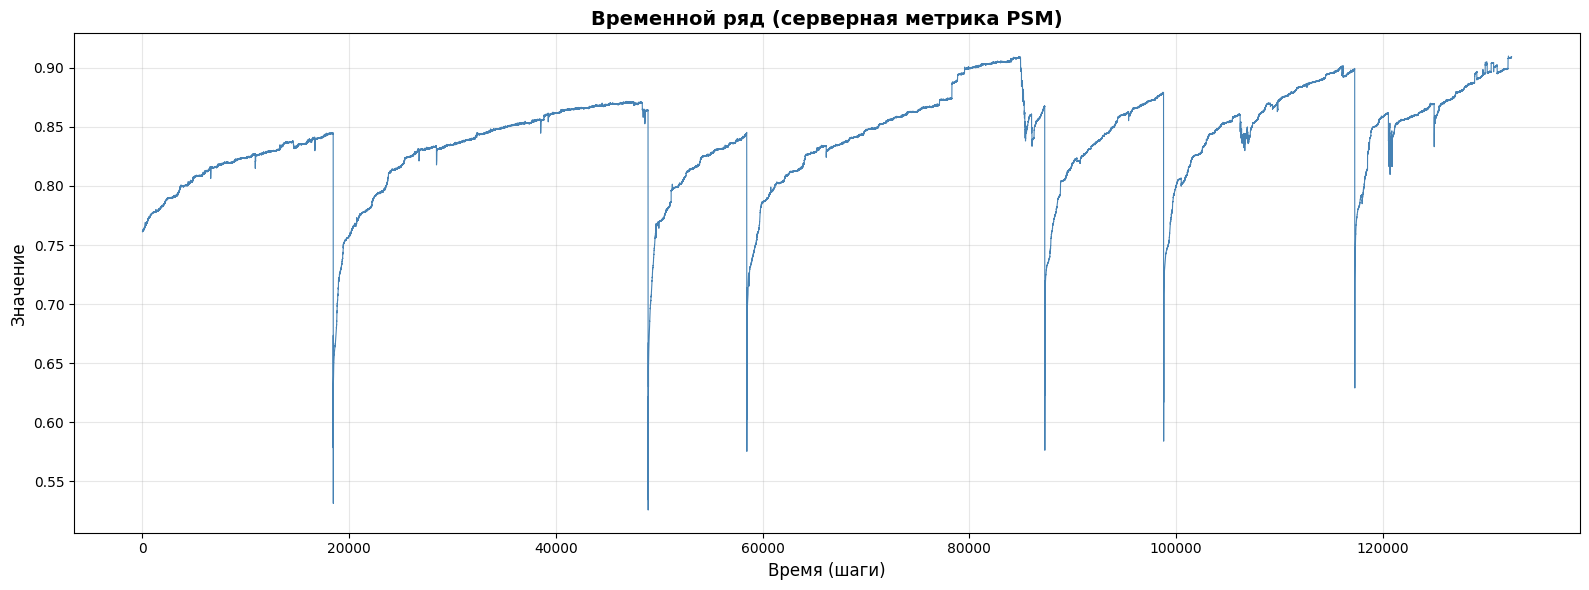

In [393]:
# 1.1 График временного ряда
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(series.values, linewidth=0.8, color='steelblue')
ax.set_title('Временной ряд (серверная метрика PSM)', fontsize=14, fontweight='bold')
ax.set_xlabel('Время (шаги)', fontsize=12)
ax.set_ylabel('Значение', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('01_time_series.png', dpi=150, bbox_inches='tight')
plt.show()

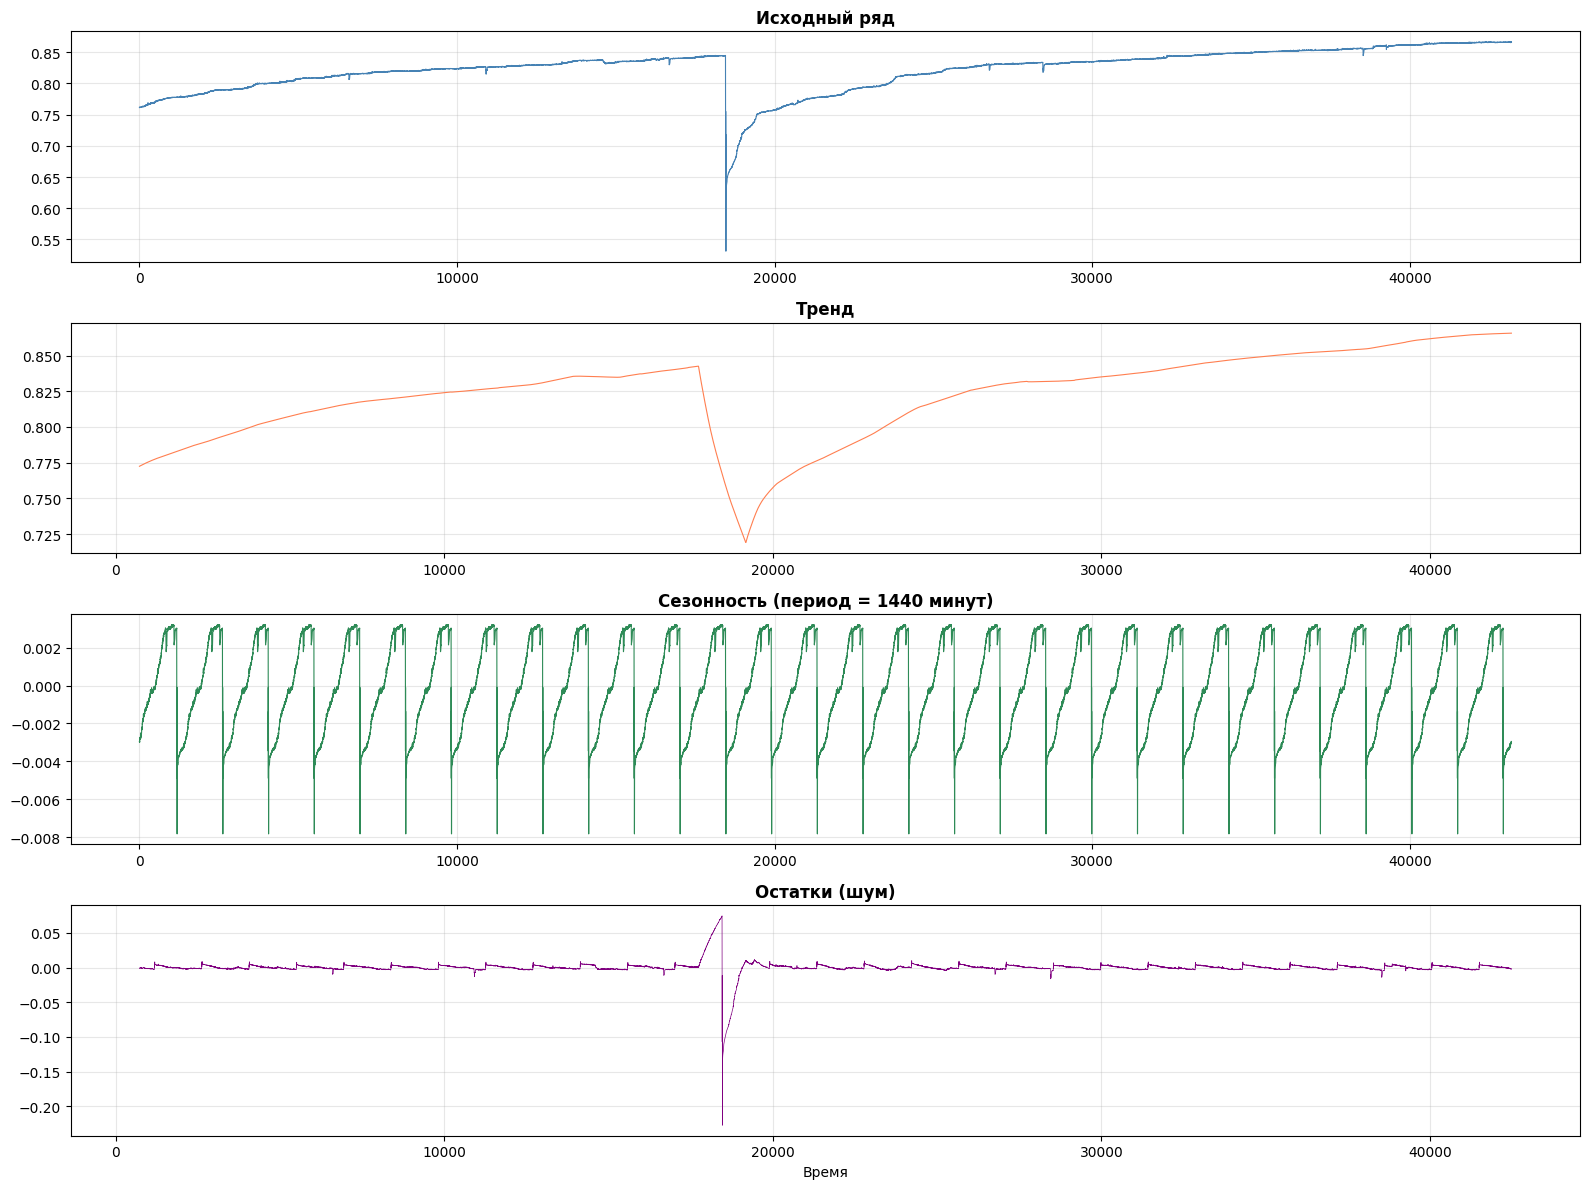

Сохранен: 02_decomposition.png


In [ ]:
# 1.2 Декомпозиция (тренд, сезонность, остатки)
try:
    decomp_length = min(43200, len(series))
    series_decomp = series[:decomp_length]
    period = 1440  # суточная сезонность (24 часа * 60 минут)
    
    decomposition = seasonal_decompose(series_decomp, model='additive', period=period)
    
    fig, axes = plt.subplots(4, 1, figsize=(16, 12))
    
    axes[0].plot(decomposition.observed, linewidth=0.8, color='steelblue')
    axes[0].set_title('Исходный ряд', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(decomposition.trend, linewidth=0.8, color='coral')
    axes[1].set_title('Тренд', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    axes[2].plot(decomposition.seasonal, linewidth=0.8, color='seagreen')
    axes[2].set_title(f'Сезонность (период = {period} минут)', fontsize=12, fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    
    axes[3].plot(decomposition.resid, linewidth=0.5, color='purple')
    axes[3].set_title('Остатки (шум)', fontsize=12, fontweight='bold')
    axes[3].set_xlabel('Время', fontsize=10)
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('02_decomposition.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Сохранен: 02_decomposition.png")
except Exception as e:
    print(f"Декомпозиция не выполнена: {e}")

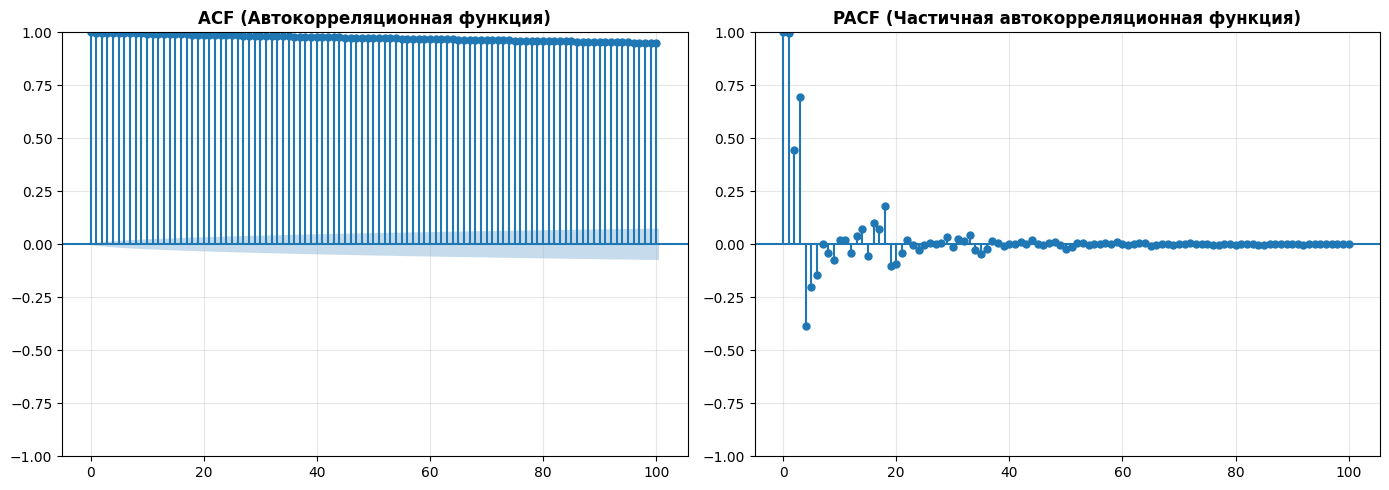

Сохранен: 03_acf_pacf.png


In [395]:
# 1.3 ACF и PACF графики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(series, lags=min(100, len(series)//10), ax=axes[0], alpha=0.05)
axes[0].set_title('ACF (Автокорреляционная функция)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

plot_pacf(series, lags=min(100, len(series)//10), ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('PACF (Частичная автокорреляционная функция)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранен: 03_acf_pacf.png")

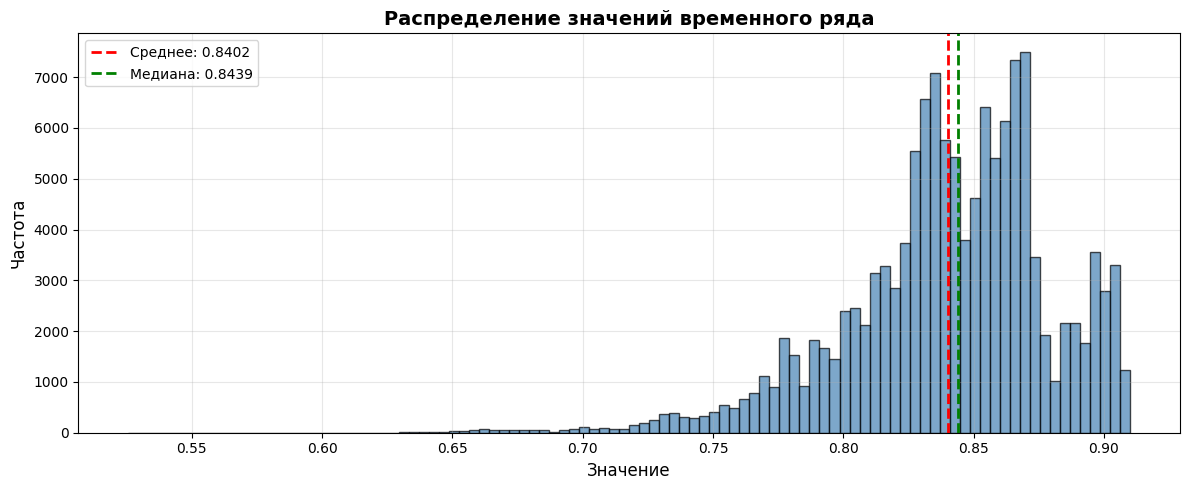

Сохранен: 04_histogram.png


In [397]:
# 1.4 Гистограмма распределения
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(series.dropna(), bins=100, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(series.mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {series.mean():.4f}')
ax.axvline(series.median(), color='green', linestyle='--', linewidth=2, label=f'Медиана: {series.median():.4f}')
ax.set_title('Распределение значений временного ряда', fontsize=14, fontweight='bold')
ax.set_xlabel('Значение', fontsize=12)
ax.set_ylabel('Частота', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('04_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранен: 04_histogram.png")

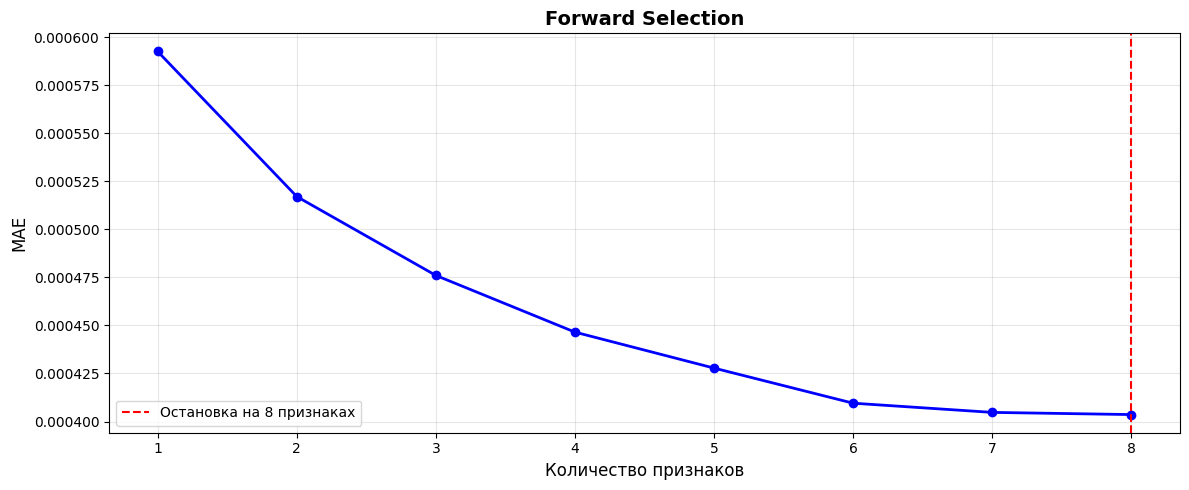

Сохранен: 05_forward_selection.png


In [403]:
# 2.1 График Forward Selection
if 'forward_mae_history' in dir() and forward_mae_history:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(range(1, len(forward_mae_history) + 1), forward_mae_history, 
            'bo-', linewidth=2, markersize=6)
    ax.set_xlabel('Количество признаков', fontsize=12)
    ax.set_ylabel('MAE', fontsize=12)
    ax.set_title('Forward Selection', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Отмечаем точку остановки
    if len(forward_mae_history) < 50:
        ax.axvline(x=len(forward_mae_history), color='red', linestyle='--', 
                   label=f'Остановка на {len(forward_mae_history)} признаках')
        ax.legend()
    
    plt.tight_layout()
    plt.savefig('05_forward_selection.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Сохранен: 05_forward_selection.png")


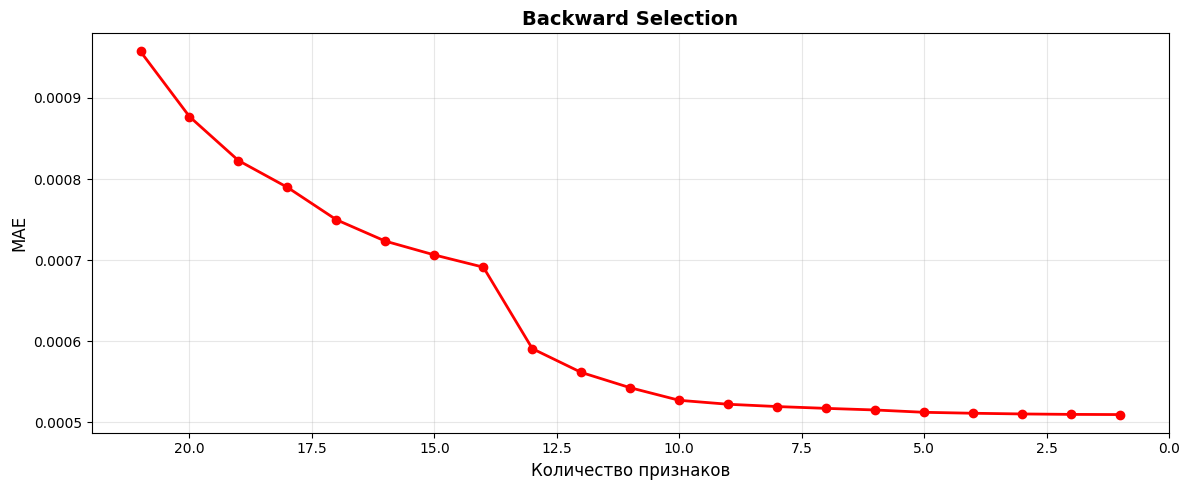

Сохранен: 06_backward_selection.png


In [402]:
if 'backward_mae_history' in dir() and backward_mae_history:
    fig, ax = plt.subplots(figsize=(12, 5))
    n_features_start = len(backward_mae_history)
    x_backward = list(range(n_features_start, 0, -1))
    ax.plot(x_backward, backward_mae_history, 'ro-', linewidth=2, markersize=6)
    ax.set_xlabel('Количество признаков', fontsize=12)
    ax.set_ylabel('MAE', fontsize=12)
    ax.set_title('Backward Selection', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.invert_xaxis()
    
    plt.tight_layout()
    plt.savefig('06_backward_selection.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Сохранен: 06_backward_selection.png")

In [415]:
# 2.3 Сравнительная таблица финальных наборов признаков
print("\nСравнительная таблица финальных наборов признаков:")

comparison_table = pd.DataFrame({
    'Метод': ['Forward Selection', 'Backward Selection'],
    'Количество признаков': [len(forward_selected) if 'forward_selected' in dir() else '?', 
                              len(backward_selected) if 'backward_selected' in dir() else '?'],
    'Итоговая MAE': [forward_mae_history[-1] if 'forward_mae_history' in dir() else '?',
                      backward_mae_history[-1] if 'backward_mae_history' in dir() else '?']
})

comparison_table
# comparison_table.to_csv('07_feature_comparison.csv', index=False)
# print("   ✅ Сохранен: 07_feature_comparison.csv")



Сравнительная таблица финальных наборов признаков:


,Метод,Количество признаков,Итоговая MAE
0,Forward Selection,7,0.000404
1,Backward Selection,10,0.000510


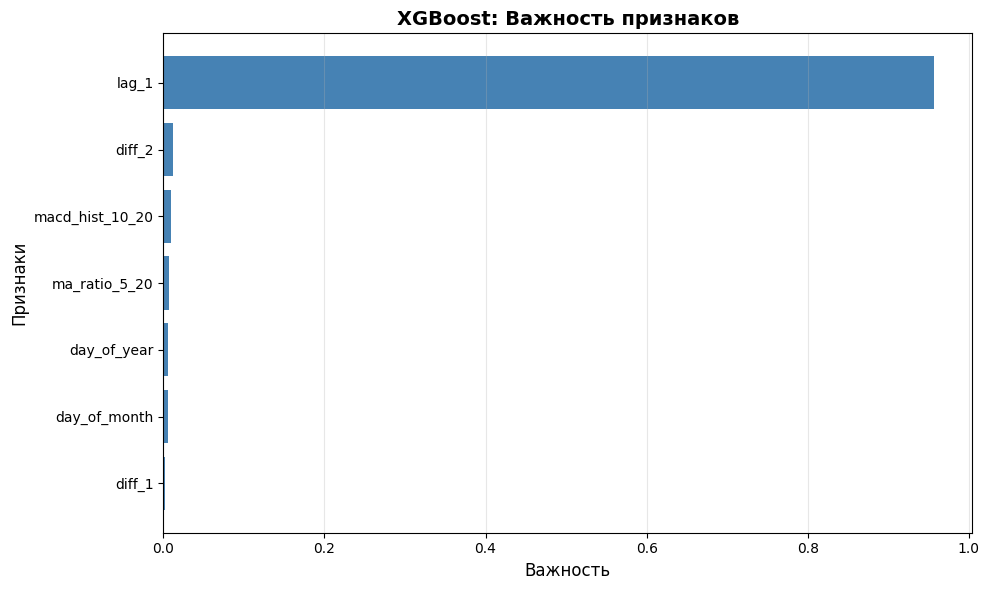

Сохранен: 08_xgboost_importance.png


In [406]:
# 2.4 Feature Importance для XGBoost
if 'xgb_final' in dir():
    importance_df = pd.DataFrame({
        'feature': forward_selected,
        'importance': xgb_final.feature_importances_
    }).sort_values('importance', ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
    ax.set_xlabel('Важность', fontsize=12)
    ax.set_ylabel('Признаки', fontsize=12)
    ax.set_title('XGBoost: Важность признаков', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig('08_xgboost_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Сохранен: 08_xgboost_importance.png")

In [422]:
# 3.1 Сводная таблица всех метрик
if 'summary' in dir():
    print("\n📊 Сводная таблица метрик:")
    print(summary.to_string(index=False))
    summary.to_csv('09_model_comparison.csv', index=False)
    print("Сохранен: 09_model_comparison.csv")



📊 Сводная таблица метрик:
 Модель      MAE    RMSE  R²
  Ridge 0.000690 0.00164 NaN
XGBoost 0.001169 0.00277 NaN
Сохранен: 09_model_comparison.csv


In [429]:
def calculate_all_metrics(y_true, y_pred, model_name):
    """Рассчитывает все метрики для модели"""
    
    # Преобразуем в numpy массивы и делаем одномерными
    if hasattr(y_true, 'values'):
        y_true = y_true.values.flatten()
    else:
        y_true = np.array(y_true).flatten()
    
    if hasattr(y_pred, 'values'):
        y_pred = y_pred.values.flatten()
    else:
        y_pred = np.array(y_pred).flatten()
    
    min_len = min(len(y_true), len(y_pred))
    y_true = y_true[:min_len]
    y_pred = y_pred[:min_len]
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    denominator = np.abs(y_true) + 1e-8
    mape = np.mean(np.abs((y_true - y_pred) / denominator)) * 100
    
    denominator_smape = np.abs(y_true) + np.abs(y_pred) + 1e-8
    smape = np.mean(2 * np.abs(y_pred - y_true) / denominator_smape) * 100
    
    print(f"\n   {model_name}:")
    print(f"MAE:  {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R^2:   {r2:.6f}")
    print(f"MAPE: {mape:.4f}%")
    print(f"SMAPE:{smape:.4f}%")
    
    return {'MAE': mae, 'RMSE': rmse, 'R^2': r2, 'MAPE': mape, 'SMAPE': smape}


In [430]:
metrics = {}

# Ridge
if 'y_test' in dir() and 'y_pred_ridge_test' in dir():
    metrics['Ridge'] = calculate_all_metrics(y_test, y_pred_ridge_test, 'Ridge')

# XGBoost
if 'y_test' in dir() and 'y_pred_xgb_test' in dir():
    metrics['XGBoost'] = calculate_all_metrics(y_test, y_pred_xgb_test, 'XGBoost')

# LSTM
if 'y_test_lstm' in dir() and 'y_pred_lstm_test' in dir():
    metrics['LSTM'] = calculate_all_metrics(y_test_lstm, y_pred_lstm_test, 'LSTM')
elif 'y_test' in dir() and 'y_pred_lstm_test' in dir():
    metrics['LSTM'] = calculate_all_metrics(y_test, y_pred_lstm_test, 'LSTM')


   Ridge:
MAE:  0.000690
RMSE: 0.001640
R^2:   0.996759
MAPE: 0.0810%
SMAPE:0.0809%

   XGBoost:
MAE:  0.001169
RMSE: 0.002770
R^2:   0.990758
MAPE: 0.1338%
SMAPE:0.1337%

   LSTM:
MAE:  0.001186
RMSE: 0.007072
R^2:   0.939717
MAPE: 0.1377%
SMAPE:0.1409%


In [436]:
if metrics:
    summary_data = {
        'Модель': list(metrics.keys()),
        'MAE': [metrics[m]['MAE'] for m in metrics],
        'RMSE': [metrics[m]['RMSE'] for m in metrics],
        'R^2': [metrics[m]['R^2'] for m in metrics],
        'MAPE (%)': [metrics[m]['MAPE'] for m in metrics],
        'SMAPE (%)': [metrics[m]['SMAPE'] for m in metrics]
    }
    
    summary = pd.DataFrame(summary_data)
    summary = summary.sort_values('MAE')  
    
    print(summary.to_string(index=False))
    
    # Определяем лучшую модель
    best_model = summary.loc[summary['MAE'].idxmin(), 'Модель']
    best_mae = summary['MAE'].min()
    
    print(f"\nЛУЧШАЯ МОДЕЛЬ: {best_model.upper()} (MAE = {best_mae:.6f})")



 Модель      MAE     RMSE      R^2  MAPE (%)  SMAPE (%)
  Ridge 0.000690 0.001640 0.996759  0.080999   0.080865
XGBoost 0.001169 0.002770 0.990758  0.133775   0.133734
   LSTM 0.001186 0.007072 0.939717  0.137683   0.140857

ЛУЧШАЯ МОДЕЛЬ: RIDGE (MAE = 0.000690)


Лучшая модель: Ridge


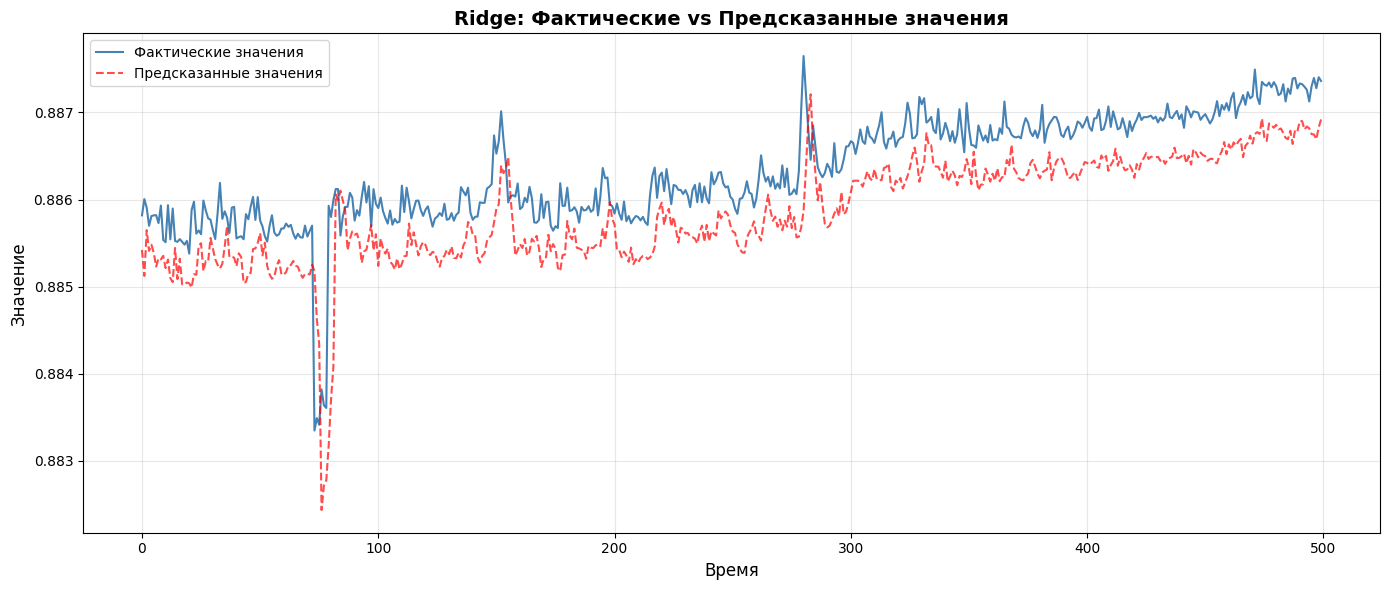

Сохранен: 10_predictions_vs_actual.png


In [444]:
best_model = summary.loc[summary['MAE'].idxmin(), 'Модель']
print(f"Лучшая модель: {best_model}")
y_pred_best = y_pred_ridge

if y_pred_best is not None and 'y_true' in dir():
    min_len = min(len(y_true), len(y_pred_best))
    y_true_plot = y_true[:min_len].values if hasattr(y_true[:min_len], 'values') else y_true[:min_len]
    y_pred_plot = y_pred_best[:min_len]
    
    plt.figure(figsize=(14, 6))
    
    n_show = 500
    plt.plot(y_true_plot[:n_show], label='Фактические значения', linewidth=1.5, color='steelblue')
    plt.plot(y_pred_plot[:n_show], label='Предсказанные значения', linewidth=1.5, 
             color='red', linestyle='--', alpha=0.7)
    plt.xlabel('Время', fontsize=12)
    plt.ylabel('Значение', fontsize=12)
    plt.title(f'{best_model}: Фактические vs Предсказанные значения', 
              fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('10_predictions_vs_actual.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Сохранен: 10_predictions_vs_actual.png")

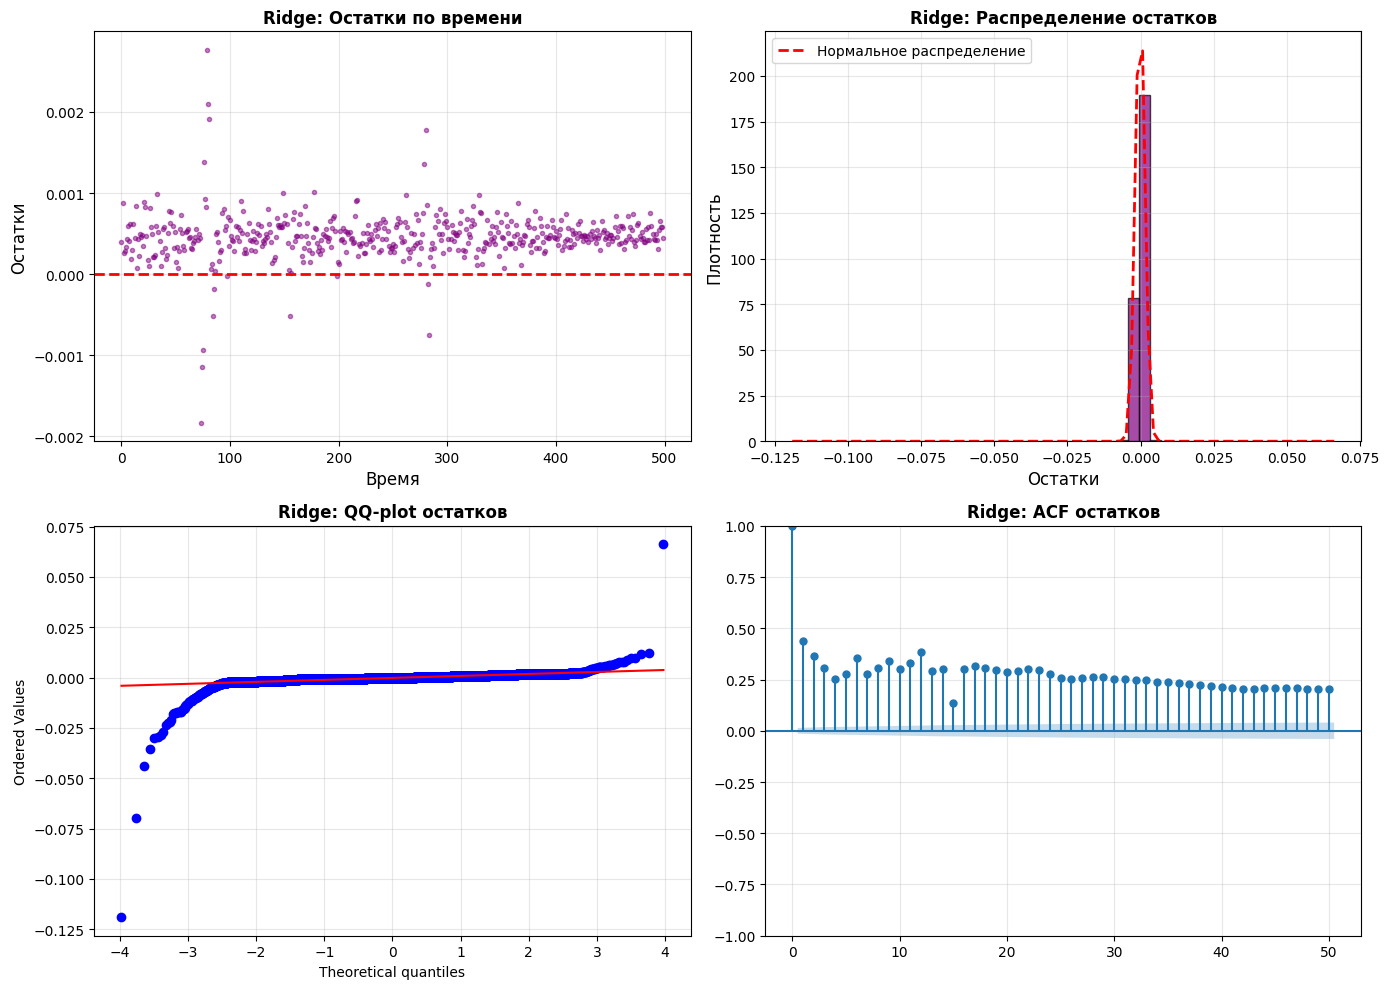

Сохранен: 11_residuals_analysis.png


In [446]:
if y_pred_best is not None and 'y_true' in dir():
    residuals = y_true_plot - y_pred_plot
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # График 1: Остатки по времени
    axes[0, 0].plot(residuals[:n_show], 'o', alpha=0.5, markersize=3, color='purple')
    axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[0, 0].set_xlabel('Время', fontsize=12)
    axes[0, 0].set_ylabel('Остатки', fontsize=12)
    axes[0, 0].set_title(f'{best_model}: Остатки по времени', fontsize=12, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    
    # График 2: Гистограмма остатков
    axes[0, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='purple', density=True)
    axes[0, 1].set_xlabel('Остатки', fontsize=12)
    axes[0, 1].set_ylabel('Плотность', fontsize=12)
    axes[0, 1].set_title(f'{best_model}: Распределение остатков', fontsize=12, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    
    # нормальное распределение для сравнения
    mu, std = np.mean(residuals), np.std(residuals)
    x = np.linspace(residuals.min(), residuals.max(), 100)
    axes[0, 1].plot(x, stats.norm.pdf(x, mu, std), 'r--', linewidth=2, label='Нормальное распределение')
    axes[0, 1].legend()
    
    # График 3: QQ-plot
    stats.probplot(residuals, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title(f'{best_model}: QQ-plot остатков', fontsize=12, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    
    # График 4: ACF остатков
    from statsmodels.graphics.tsaplots import plot_acf
    plot_acf(residuals, lags=min(50, len(residuals)//10), ax=axes[1, 1], alpha=0.05)
    axes[1, 1].set_title(f'{best_model}: ACF остатков', fontsize=12, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('11_residuals_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Сохранен: 11_residuals_analysis.png")
    


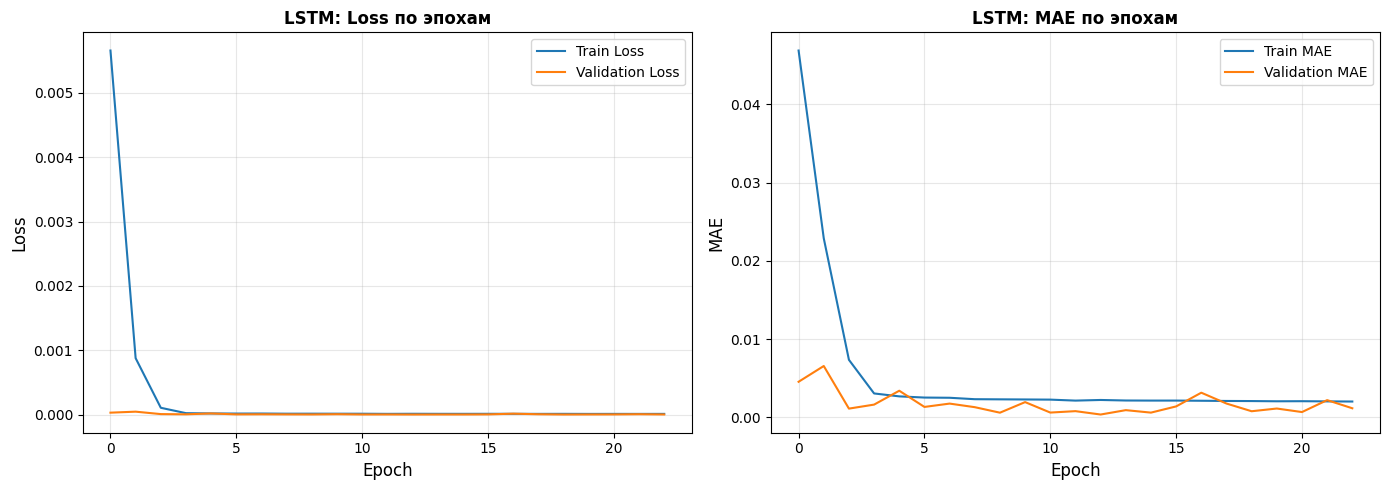

Сохранен: 13_lstm_learning_curves.png


In [448]:
if lstm_history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # График 1: Loss
    axes[0].plot(lstm_history.history['loss'], label='Train Loss', linewidth=1.5)
    axes[0].plot(lstm_history.history['val_loss'], label='Validation Loss', linewidth=1.5)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('LSTM: Loss по эпохам', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # График 2: MAE
    if 'mae' in lstm_history.history:
        axes[1].plot(lstm_history.history['mae'], label='Train MAE', linewidth=1.5)
        axes[1].plot(lstm_history.history['val_mae'], label='Validation MAE', linewidth=1.5)
        axes[1].set_xlabel('Epoch', fontsize=12)
        axes[1].set_ylabel('MAE', fontsize=12)
        axes[1].set_title('LSTM: MAE по эпохам', fontsize=12, fontweight='bold')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('13_lstm_learning_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Сохранен: 13_lstm_learning_curves.png")



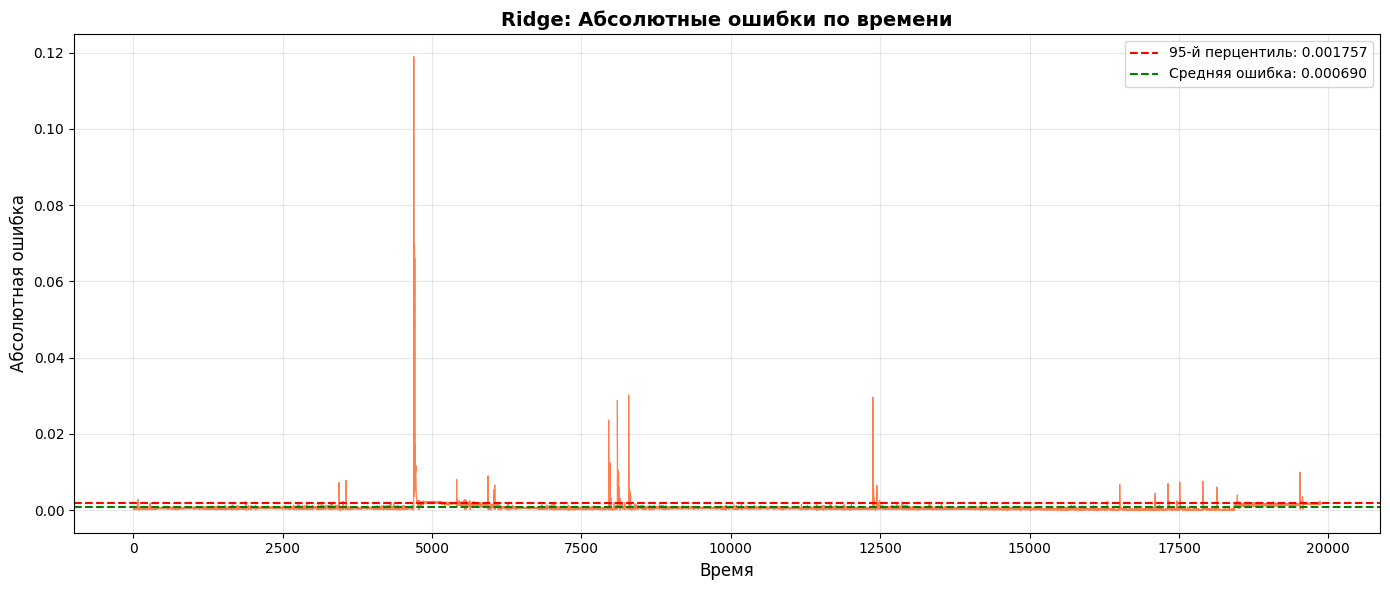

Сохранен: 14_errors_over_time.png


In [450]:
if y_pred_best is not None and 'y_true' in dir():
    errors = np.abs(residuals)
    
    plt.figure(figsize=(14, 6))
    plt.plot(errors, linewidth=0.8, color='coral') 
    plt.axhline(y=np.percentile(errors, 95), color='red', linestyle='--', 
               label=f'95-й перцентиль: {np.percentile(errors, 95):.6f}')
    plt.axhline(y=np.mean(errors), color='green', linestyle='--', 
               label=f'Средняя ошибка: {np.mean(errors):.6f}')
    plt.xlabel('Время', fontsize=12)
    plt.ylabel('Абсолютная ошибка', fontsize=12)
    plt.title(f'{best_model}: Абсолютные ошибки по времени', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('14_errors_over_time.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Сохранен: 14_errors_over_time.png")


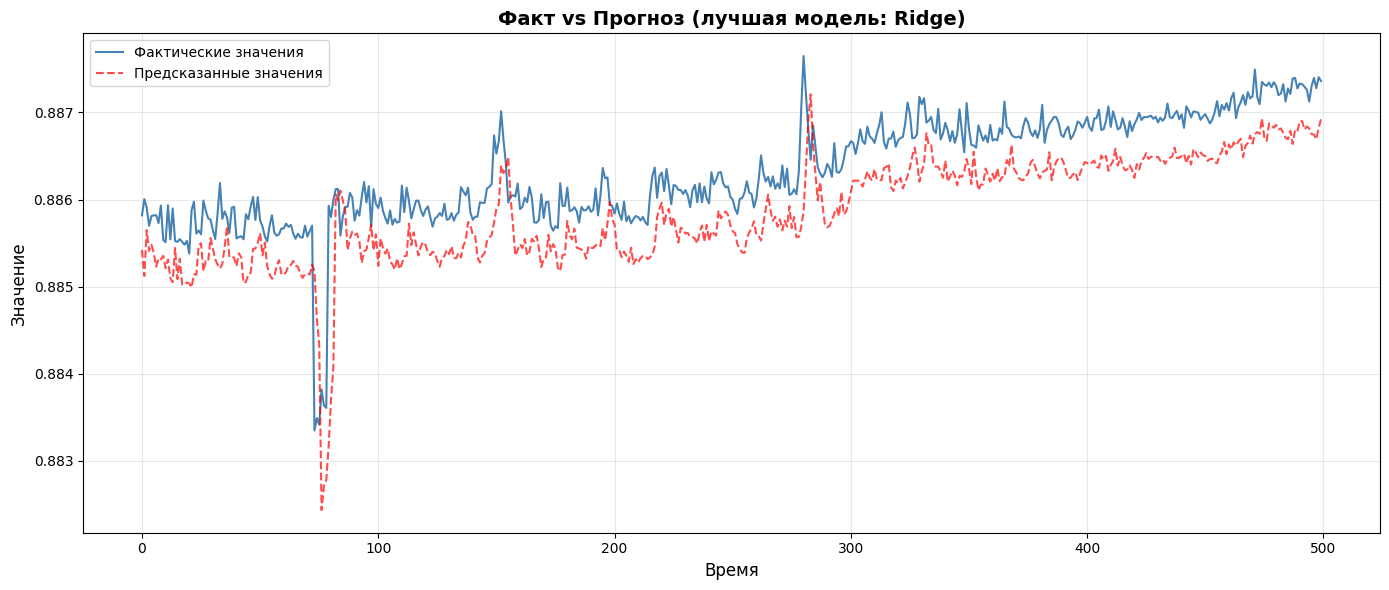

   ✅ Сохранен: 10_predictions_vs_actual.png


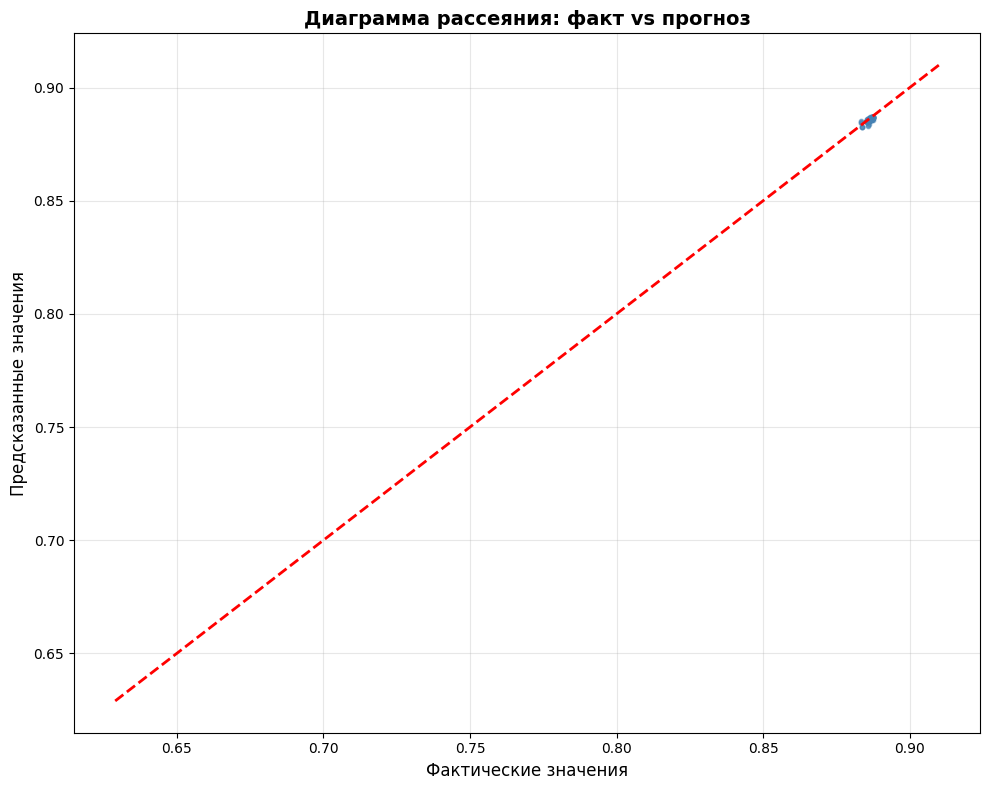

   ✅ Сохранен: 11_scatter_plot.png


In [ ]:

# ============================================
# 7. ВЫЯВЛЕНИЕ ПЕРИОДОВ С НАИБОЛЬШИМИ ОШИБКАМИ
# ============================================

print("\n" + "="*80)
print("7️⃣ ВЫЯВЛЕНИЕ ПЕРИОДОВ С НАИБОЛЬШИМИ ОШИБКАМИ")
print("="*80)

if y_pred_best is not None and 'y_true' in dir():
    # Создаем DataFrame с ошибками
    error_df = pd.DataFrame({
        'error': errors,
        'index': range(len(errors))
    })
    
    # Топ-10 наибольших ошибок
    top_errors = error_df.nlargest(10, 'error')
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # График 1: Ошибки по часам (если есть временная привязка)
    error_df['hour'] = error_df['index'] % 24
    hourly_errors = error_df.groupby('hour')['error'].mean()
    top_hours = hourly_errors.nlargest(3).index.tolist()
    
    axes[0].bar(hourly_errors.index, hourly_errors.values, color='steelblue', alpha=0.7)
    axes[0].set_xlabel('Час дня', fontsize=12)
    axes[0].set_ylabel('Средняя абсолютная ошибка', fontsize=12)
    axes[0].set_title(f'{best_model}: Ошибки по часам суток', fontsize=12, fontweight='bold')
    axes[0].set_xticks(range(0, 24, 3))
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # График 2: Топ-10 наибольших ошибок
    axes[1].barh(range(len(top_errors)), top_errors['error'].values, color='coral', alpha=0.7)
    axes[1].set_yticks(range(len(top_errors)))
    axes[1].set_yticklabels([f"Шаг {idx}" for idx in top_errors['index'].values])
    axes[1].set_xlabel('Абсолютная ошибка', fontsize=12)
    axes[1].set_title(f'{best_model}: Топ-10 наибольших ошибок', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('15_peak_errors.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("   ✅ Сохранен: 15_peak_errors.png")
    
    # Сохраняем
    hourly_errors.to_csv('16_hourly_errors.csv')
    top_errors.to_csv('17_top_errors.csv', index=False)
    print("   ✅ Сохранен: 16_hourly_errors.csv")
    print("   ✅ Сохранен: 17_top_errors.csv")

print("\n" + "="*80)
print("✅ ВСЕ ГРАФИКИ И ТАБЛИЦЫ ДЛЯ ОТЧЕТА СОЗДАНЫ!")
print("="*80)

In [ ]:

# 3.3 Графики остатков (residuals)
if 'y_pred_best' in dir():
    residuals = y_test[:n_show].values - y_pred_best[:n_show]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Остатки по времени
    axes[0].plot(residuals, 'o', alpha=0.5, markersize=3, color='purple')
    axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[0].set_xlabel('Время', fontsize=12)
    axes[0].set_ylabel('Остатки', fontsize=12)
    axes[0].set_title('Остатки по времени', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Гистограмма остатков
    axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='purple')
    axes[1].set_xlabel('Остатки', fontsize=12)
    axes[1].set_ylabel('Частота', fontsize=12)
    axes[1].set_title('Распределение остатков', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('12_residuals.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("   ✅ Сохранен: 12_residuals.png")

# 3.4 Learning curves для LSTM
if 'best_history' in dir() and best_history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(best_history.history['loss'], label='Train Loss', linewidth=1.5)
    axes[0].plot(best_history.history['val_loss'], label='Val Loss', linewidth=1.5)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('LSTM: Loss по эпохам', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(best_history.history['mae'], label='Train MAE', linewidth=1.5)
    axes[1].plot(best_history.history['val_mae'], label='Val MAE', linewidth=1.5)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('MAE', fontsize=12)
    axes[1].set_title('LSTM: MAE по эпохам', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('13_lstm_learning_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("   ✅ Сохранен: 13_lstm_learning_curves.png")

# ============================================
# 4. АНАЛИЗ ОШИБОК
# ============================================

print("\n" + "="*80)
print("4. АНАЛИЗ ОШИБОК")
print("="*80)

if 'y_pred_best' in dir():
    # 4.1 Временные графики ошибок предсказания
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(np.abs(residuals), linewidth=0.8, color='coral')
    ax.set_xlabel('Время', fontsize=12)
    ax.set_ylabel('Абсолютная ошибка', fontsize=12)
    ax.set_title('Временной график абсолютных ошибок предсказания', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('14_errors_over_time.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("   ✅ Сохранен: 14_errors_over_time.png")
    
    # 4.2 QQ-plot остатков
    from scipy import stats
    fig, ax = plt.subplots(figsize=(8, 8))
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title('QQ-plot остатков (проверка нормальности)', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('15_qq_plot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("   ✅ Сохранен: 15_qq_plot.png")
    
    # 4.3 Выявление периодов с наибольшими ошибками
    # Группировка по часам
    errors_df = pd.DataFrame({
        'error': np.abs(residuals),
        'index': range(len(residuals))
    })
    
    # Создаем временные метки
    errors_df['hour'] = errors_df['index'] % 24
    
    # Средняя ошибка по часам
    hourly_errors = errors_df.groupby('hour')['error'].mean()
    
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(hourly_errors.index, hourly_errors.values, color='steelblue', alpha=0.7)
    ax.set_xlabel('Час дня', fontsize=12)
    ax.set_ylabel('Средняя абсолютная ошибка', fontsize=12)
    ax.set_title('Ошибки предсказания по часам суток', fontsize=14, fontweight='bold')
    ax.set_xticks(range(0, 24, 3))
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('16_hourly_errors.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("   ✅ Сохранен: 16_hourly_errors.png")
    
    # Статистика ошибок
    print("\n📊 Статистика ошибок:")
    error_stats = pd.DataFrame({
        'Метрика': ['MAE', 'RMSE', 'Максимальная ошибка', '95-й перцентиль', 'Медиана ошибки'],
        'Значение': [
            np.mean(np.abs(residuals)),
            np.sqrt(np.mean(residuals**2)),
            np.max(np.abs(residuals)),
            np.percentile(np.abs(residuals), 95),
            np.median(np.abs(residuals))
        ]
    })
    print(error_stats.to_string(index=False))
    error_stats.to_csv('17_error_statistics.csv', index=False)
    print("   ✅ Сохранен: 17_error_statistics.csv")

# ============================================
# 5. ИТОГОВЫЙ СПИСОК ФАЙЛОВ
# ============================================

print("\n" + "="*80)
print("ИТОГОВЫЙ СПИСОК СОХРАНЕННЫХ ФАЙЛОВ")
print("="*80)

files_list = [
    "01_time_series.png - График временного ряда",
    "02_decomposition.png - Декомпозиция (тренд, сезонность, остатки)",
    "03_acf_pacf.png - ACF и PACF графики",
    "04_histogram.png - Гистограмма распределения",
    "05_forward_selection.png - Forward Selection: изменение MAE",
    "06_backward_selection.png - Backward Selection: изменение MAE",
    "07_feature_comparison.csv - Сравнение наборов признаков",
    "08_xgboost_importance.png - Feature importance XGBoost",
    "09_model_comparison.csv - Сравнение метрик моделей",
    "10_predictions_vs_actual.png - Факт vs прогноз (линии)",
    "11_scatter_plot.png - Факт vs прогноз (точечный график)",
    "12_residuals.png - Остатки (время + гистограмма)",
    "13_lstm_learning_curves.png - Learning curves LSTM",
    "14_errors_over_time.png - Ошибки во времени",
    "15_qq_plot.png - QQ-plot остатков",
    "16_hourly_errors.png - Ошибки по часам",
    "17_error_statistics.csv - Статистика ошибок"
]

for f in files_list:
    print(f"   📁 {f}")

print("\n" + "="*80)
print("✅ ВСЕ ГРАФИКИ И ТАБЛИЦЫ СОЗДАНЫ!")
print("="*80)

In [ ]:

# ============================================
# 8. РЕЗУЛЬТАТЫ ПОДБОРА
# ============================================

print("\n" + "="*80)
print("РЕЗУЛЬТАТЫ ПОДБОРА ГИПЕРПАРАМЕТРОВ")
print("="*80)

if best_params:
    print("\n✅ Лучшие гиперпараметры:")
    for key, value in best_params.items():
        print(f"   {key}: {value}")
    print(f"   Лучшая MAE: {best_mae:.6f}")

# Сохраняем результаты подбора
results_df = pd.DataFrame(results)
results_df.to_csv('lstm_grid_search_results.csv', index=False)
print(f"\n   ✅ Сохранено lstm_grid_search_results.csv")

# ============================================
# 9. ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ С ЛУЧШИМИ ПАРАМЕТРАМИ
# ============================================

print("\n" + "="*80)
print("ОБУЧЕНИЕ ФИНАЛЬНОЙ LSTM МОДЕЛИ")
print("="*80)

if best_params:
    # Создаем последовательности с лучшими параметрами
    seq_len = best_params['seq_len']
    batch_size = best_params['batch_size']
    
    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, seq_len)
    X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val.values, seq_len)
    X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test.values, seq_len)
    
    print(f"\n   Данные после создания последовательностей:")
    print(f"   Train: {X_train_seq.shape}")
    print(f"   Val:   {X_val_seq.shape}")
    print(f"   Test:  {X_test_seq.shape}")
    
    # Создаем финальную модель
    final_model = create_lstm_model(
        seq_len=seq_len,
        n_features=X_train_scaled.shape[1],
        lstm1_units=best_params['lstm1_units'],
        lstm2_units=best_params['lstm2_units'],
        dropout_rate=best_params['dropout_rate'],
        learning_rate=best_params['learning_rate']
    )
    
    print("\n   Архитектура финальной модели:")
    final_model.summary()
    
    # Early stopping
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=best_params['patience'],
        restore_best_weights=True,
        verbose=1
    )
    
    # Обучение финальной модели
    print("\n   Обучение финальной модели...")
    final_history = final_model.fit(
        X_train_seq, y_train_seq,
        epochs=best_params['epochs'],
        batch_size=batch_size,
        validation_data=(X_val_seq, y_val_seq),
        callbacks=[early_stop],
        verbose=1
    )
    
    # ============================================
    # 10. ОЦЕНКА ФИНАЛЬНОЙ МОДЕЛИ
    # ============================================
    
    print("\n" + "="*80)
    print("ОЦЕНКА LSTM МОДЕЛИ НА ТЕСТОВЫХ ДАННЫХ")
    print("="*80)
    
    # Предсказания
    y_pred_train = final_model.predict(X_train_seq, verbose=0)
    y_pred_val = final_model.predict(X_val_seq, verbose=0)
    y_pred_test = final_model.predict(X_test_seq, verbose=0)
    
    # Метрики
    def calculate_metrics(y_true, y_pred):
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        return {'MAE': mae, 'RMSE': rmse, 'R²': r2}
    
    train_metrics = calculate_metrics(y_train_seq, y_pred_train)
    val_metrics = calculate_metrics(y_val_seq, y_pred_val)
    test_metrics = calculate_metrics(y_test_seq, y_pred_test)
    
    print(f"\n   📊 Результаты LSTM:")
    print(f"   Train MAE: {train_metrics['MAE']:.6f}")
    print(f"   Train R²:  {train_metrics['R²']:.4f}")
    print(f"   Val   MAE: {val_metrics['MAE']:.6f}")
    print(f"   Val   R²:  {val_metrics['R²']:.4f}")
    print(f"   Test  MAE: {test_metrics['MAE']:.6f}")
    print(f"   Test  R²:  {test_metrics['R²']:.4f}")

# ============================================
# 11. ВИЗУАЛИЗАЦИЯ
# ============================================

if best_model:
    print("\n" + "="*80)
    print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
    print("="*80)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # График 1: Learning Curves
    axes[0, 0].plot(final_history.history['loss'], label='Train Loss')
    axes[0, 0].plot(final_history.history['val_loss'], label='Val Loss')
    axes[0, 0].set_xlabel('Epoch', fontsize=11)
    axes[0, 0].set_ylabel('Loss', fontsize=11)
    axes[0, 0].set_title('LSTM Learning Curves (Loss)', fontsize=12, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # График 2: MAE по эпохам
    axes[0, 1].plot(final_history.history['mae'], label='Train MAE')
    axes[0, 1].plot(final_history.history['val_mae'], label='Val MAE')
    axes[0, 1].set_xlabel('Epoch', fontsize=11)
    axes[0, 1].set_ylabel('MAE', fontsize=11)
    axes[0, 1].set_title('LSTM Learning Curves (MAE)', fontsize=12, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # График 3: Факт vs Прогноз (тест)
    sample_size = min(200, len(y_test_seq))
    axes[1, 0].scatter(y_test_seq[:sample_size], y_pred_test[:sample_size], alpha=0.5, s=10)
    axes[1, 0].plot([y_test_seq.min(), y_test_seq.max()], 
                    [y_test_seq.min(), y_test_seq.max()], 'r--', linewidth=2)
    axes[1, 0].set_xlabel('Фактические значения', fontsize=11)
    axes[1, 0].set_ylabel('Предсказанные значения', fontsize=11)
    axes[1, 0].set_title(f'Факт vs Прогноз (Test, MAE={test_metrics["MAE"]:.6f})', 
                         fontsize=12, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    
    # График 4: Остатки
    residuals = y_test_seq[:sample_size] - y_pred_test[:sample_size].flatten()
    axes[1, 1].plot(residuals, 'o', alpha=0.5, markersize=3)
    axes[1, 1].axhline(y=0, color='red', linestyle='--')
    axes[1, 1].set_xlabel('Наблюдение', fontsize=11)
    axes[1, 1].set_ylabel('Остатки', fontsize=11)
    axes[1, 1].set_title('Остатки модели', fontsize=12, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Сохраняем модель
    final_model.save('lstm_best_model.h5')
    print("\n   ✅ Модель сохранена: lstm_best_model.h5")

# ============================================
# 12. СОХРАНЕНИЕ ВСЕХ РЕЗУЛЬТАТОВ
# ============================================

print("\n💾 Сохранение результатов...")

# Сохраняем метрики
if best_model:
    metrics_summary = pd.DataFrame({
        'Dataset': ['Train', 'Validation', 'Test'],
        'MAE': [train_metrics['MAE'], val_metrics['MAE'], test_metrics['MAE']],
        'RMSE': [train_metrics['RMSE'], val_metrics['RMSE'], test_metrics['RMSE']],
        'R²': [train_metrics['R²'], val_metrics['R²'], test_metrics['R²']]
    })
    metrics_summary.to_csv('lstm_metrics.csv', index=False)
    print("   ✅ lstm_metrics.csv")

# Сохраняем предсказания
if best_model:
    predictions_df = pd.DataFrame({
        'actual': y_test_seq.flatten(),
        'predicted': y_pred_test.flatten()
    })
    predictions_df.to_csv('lstm_predictions.csv', index=False)
    print("   ✅ lstm_predictions.csv")

print("\n" + "="*80)
print("✅ LSTM ОБУЧЕНИЕ ЗАВЕРШЕНО!")
print("="*80)

if best_params:
    print(f"\n📊 ИТОГОВЫЙ РЕЗУЛЬТАТ LSTM:")
    print(f"   Лучшие гиперпараметры: {best_params}")
    print(f"   Test MAE: {test_metrics['MAE']:.6f}")
    print(f"   Test R²:  {test_metrics['R²']:.4f}")

In [ ]:

# Оценка на тесте с лучшей моделью
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test.values, best_seq_len)
y_pred_lstm_test = best_model.predict(X_test_seq, verbose=0)

# Метрики LSTM
# Для train и val нужно пересчитать с правильной длиной
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, best_seq_len)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val.values, best_seq_len)

y_pred_lstm_train = best_model.predict(X_train_seq, verbose=0)
y_pred_lstm_val = best_model.predict(X_val_seq, verbose=0)

metrics_lstm_train = calculate_metrics(y_train_seq, y_pred_lstm_train.flatten())
metrics_lstm_val = calculate_metrics(y_val_seq, y_pred_lstm_val.flatten())
metrics_lstm_test = calculate_metrics(y_test_seq, y_pred_lstm_test.flatten())

print(f"\n   Результаты LSTM (seq_len={best_seq_len}):")
print(f"   Train MAE: {metrics_lstm_train['MAE']:.6f}")
print(f"   Val   MAE: {metrics_lstm_val['MAE']:.6f}")
print(f"   Test  MAE: {metrics_lstm_test['MAE']:.6f}")
print(f"   Test  R²:  {metrics_lstm_test['R²']:.4f}")

# ============================================
# 7. СВОДНАЯ ТАБЛИЦА МЕТРИК
# ============================================

print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА МЕТРИК (TEST)")
print("="*80)

summary = pd.DataFrame({
    'Модель': ['Ridge', 'XGBoost', 'LSTM'],
    'MAE': [metrics_ridge_test['MAE'], metrics_xgb_test['MAE'], metrics_lstm_test['MAE']],
    'RMSE': [metrics_ridge_test['RMSE'], metrics_xgb_test['RMSE'], metrics_lstm_test['RMSE']],
    'MAPE (%)': [metrics_ridge_test['MAPE'], metrics_xgb_test['MAPE'], metrics_lstm_test['MAPE']],
    'SMAPE (%)': [metrics_ridge_test['SMAPE'], metrics_xgb_test['SMAPE'], metrics_lstm_test['SMAPE']],
    'R²': [metrics_ridge_test['R²'], metrics_xgb_test['R²'], metrics_lstm_test['R²']]
})

print(summary.to_string(index=False))

# ============================================
# 8. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Факт vs Прогноз для лучшей модели
best_model_name = summary.loc[summary['MAE'].idxmin(), 'Модель']
if best_model_name == 'Ridge':
    y_pred_best = y_pred_ridge_test
elif best_model_name == 'XGBoost':
    y_pred_best = y_pred_xgb_test
else:
    y_pred_best = y_pred_lstm_test.flatten()

axes[0, 0].scatter(y_test[:200], y_pred_best[:200], alpha=0.5, s=10)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0, 0].set_xlabel('Фактические значения')
axes[0, 0].set_ylabel('Предсказанные значения')
axes[0, 0].set_title(f'Факт vs Прогноз (лучшая модель: {best_model_name})')
axes[0, 0].grid(True, alpha=0.3)

# График 2: Сравнение MAE моделей
models = summary['Модель'].tolist()
mae_values = summary['MAE'].tolist()
colors = ['blue', 'green', 'red']
bars = axes[0, 1].bar(models, mae_values, color=colors, alpha=0.7)
axes[0, 1].set_ylabel('MAE')
axes[0, 1].set_title('Сравнение MAE моделей')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, mae_values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                   f'{val:.6f}', ha='center', va='bottom')

# График 3: Learning Curves для LSTM
axes[1, 0].plot(best_history.history['loss'], label='Train Loss')
axes[1, 0].plot(best_history.history['val_loss'], label='Val Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('LSTM Learning Curves')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# График 4: R² сравнение
r2_values = summary['R²'].tolist()
bars = axes[1, 1].bar(models, r2_values, color=colors, alpha=0.7)
axes[1, 1].set_ylabel('R²')
axes[1, 1].set_title('Сравнение R² моделей')
axes[1, 1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, r2_values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                   f'{val:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# ============================================
# 9. АНАЛИЗ ОСТАТКОВ (для лучшей модели)
# ============================================

print("\n" + "="*80)
print("АНАЛИЗ ОСТАТКОВ (Лучшая модель: {best_model_name})")
print("="*80)

residuals = y_test[:200] - y_pred_best[:200]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Остатки')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение остатков')
axes[0].grid(True, alpha=0.3)

axes[1].plot(residuals, 'o', alpha=0.5, markersize=3)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('Наблюдение')
axes[1].set_ylabel('Остатки')
axes[1].set_title('Остатки по порядку наблюдений')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 10. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# ============================================

print("\n💾 Сохранение результатов...")

summary.to_csv('model_comparison.csv', index=False)
print("   ✅ model_comparison.csv")

# Сохраняем метрики всех моделей
all_metrics = pd.DataFrame({
    'model': ['Ridge', 'XGBoost', 'LSTM'],
    'train_mae': [metrics_ridge_train['MAE'], metrics_xgb_train['MAE'], metrics_lstm_train['MAE']],
    'val_mae': [metrics_ridge_val['MAE'], metrics_xgb_val['MAE'], metrics_lstm_val['MAE']],
    'test_mae': [metrics_ridge_test['MAE'], metrics_xgb_test['MAE'], metrics_lstm_test['MAE']],
    'test_r2': [metrics_ridge_test['R²'], metrics_xgb_test['R²'], metrics_lstm_test['R²']]
})
all_metrics.to_csv('all_metrics.csv', index=False)

print("   ✅ all_metrics.csv")

print("\n" + "="*80)
print("✅ ОБУЧЕНИЕ МОДЕЛЕЙ ЗАВЕРШЕНО!")
print("="*80)

print(f"\n📊 ИТОГОВЫЙ РЕЗУЛЬТАТ:")
print(f"   Лучшая модель: {best_model_name}")
print(f"   Test MAE: {summary.loc[summary['Модель'] == best_model_name, 'MAE'].values[0]:.6f}")
print(f"   Test R²:  {summary.loc[summary['Модель'] == best_model_name, 'R²'].values[0]:.4f}")